In [6]:
import pandas as pd

In [7]:
import numpy as np          # NumPy für numerische Berechnungen
import seaborn as sns       # Seaborn für statistische Visualisierungen
import matplotlib.pyplot as plt  # Matplotlib für Diagramme

##### Video Game Sales Datei lesen 

In [ ]:
# CSV-Datei einlesen

df = pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv")



In [9]:
# Ersten Zeilen anzeigen
df.head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Überblick über die Daten
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB
None
      

###  Daten bereinigen

In [11]:
# Duplikate zählen
print(df.duplicated().sum())


0


In [12]:
# Fehlende Werte zählen
print(df.isnull().sum())

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64


In [13]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

### Die Verkaufswerte überprüfen.

In [14]:
df['Global_Sales']

0        82.53
1        40.24
2        35.52
3        32.77
4        31.37
         ...  
16714     0.01
16715     0.01
16716     0.01
16717     0.01
16718     0.01
Name: Global_Sales, Length: 16719, dtype: float64

In [15]:
print(df["Global_Sales"].isnull().sum())
print(df["Global_Sales"].describe())


0
count    16719.000000
mean         0.533543
std          1.547935
min          0.010000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.530000
Name: Global_Sales, dtype: float64


- Die Spalte Global_Sales enthält die weltweiten Verkaufszahlen eines Spiels.
- Die Werte sind in Millionen Einheiten angegeben.
- Beispiel: 82.53 bedeutet 82,53 Millionen verkaufte Einheiten weltweit.
- 0.01 bedeutet 10.000 verkaufte Einheiten (weil 0.01 Mio = 10.000).
df["Global_Sales"] = df["Global_Sales"] * 1_000_000



Datum bearbeiten

In [16]:
df['Year_of_Release']
#Name: Year_of_Release, Length: 16719, dtype: float64   muss to date year 

0        2006.0
1        1985.0
2        2008.0
3        2009.0
4        1996.0
          ...  
16714    2016.0
16715    2006.0
16716    2016.0
16717    2003.0
16718    2016.0
Name: Year_of_Release, Length: 16719, dtype: float64

** Spalte Year_of_Release ist aktuell als float64 gespeichert (z. B. 2006.0). Das ist unpraktisch, weil Jahre eigentlich Ganzzahlen oder Datumswerte sein sollten.
Jahr in Integer konvertieren  nur das Jahr brauchen wir.


In [17]:
df["Year_of_Release"] = df["Year_of_Release"].astype("Int64")
df["Year_of_Release"]

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16714    2016
16715    2006
16716    2016
16717    2003
16718    2016
Name: Year_of_Release, Length: 16719, dtype: Int64

In [18]:
df['Publisher'].nunique()

581

In [19]:
df['Genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy', nan], dtype=object)

### Fehlende werte bearbeiten

In [20]:
df["Developer"] = df["Developer"].fillna("Unknown")
df["Rating"] = df["Rating"].fillna("Unrated")

In [21]:
df["Rating"].unique()

array(['E', 'Unrated', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'],
      dtype=object)

In [22]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [23]:
cols = ["Critic_Score", "Critic_Count"]

# True, wenn in einer Zeile ALLE diese Spalten NaN sind
mask = df[cols].isnull().all(axis=1)

# Anzahl solcher Zeilen
print(mask.sum())



8582


In [24]:
# Beispiel: Zeilen anzeigen
print(df[mask].head())

                        Name Platform  Year_of_Release         Genre  \
1          Super Mario Bros.      NES             1985      Platform   
4   Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                     Tetris       GB             1989        Puzzle   
9                  Duck Hunt      NES             1984       Shooter   
10                Nintendogs       DS             2005    Simulation   

   Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  \
1   Nintendo     29.08      3.58      6.81         0.77         40.24   
4   Nintendo     11.27      8.89     10.22         1.00         31.37   
5   Nintendo     23.20      2.26      4.22         0.58         30.26   
9   Nintendo     26.93      0.63      0.28         0.47         28.31   
10  Nintendo      9.05     10.95      1.93         2.74         24.67   

    Critic_Score  Critic_Count User_Score  User_Count Developer   Rating  
1            NaN           NaN        NaN         NaN

### Note fhelender werte  Kritikerinformationen.
- Von insgesamt 16.817 Zeilen sind 8.582 Zeilen (~51 %) ohne Kritikerinformationen.
- Das ist mehr als die Hälfte deiner Daten – ein deutlicher Hinweis auf Datenlücken.
- Mögliche Gründe:
- Spiele wurden nie von Kritikern bewertet (z. B. sehr alte oder unbekannte Titel).
- Datenquelle ist unvollständig.
- Kritikerbewertungen wurden nicht eingetragen oder nicht erhoben.



### Datenvalidierungsschritt: prüfen, ob Global_Sales wirklich die Summe aus den vier Regionenspalten (NA_Sales, EU_Sales, JP_Sales, Other_Sales) ist.


In [25]:
df["Region_Sum"] = df["NA_Sales"] + df["EU_Sales"] + df["JP_Sales"] + df["Other_Sales"]

In [26]:
# Prüfen, ob alle Zeilen übereinstimmen
check_equal = (df["Global_Sales"] == df["Region_Sum"]).all()
print("Stimmt überall überein?", check_equal)

Stimmt überall überein? False


In [27]:
# Anzahl der Abweichungen
diff_count = (df["Global_Sales"] != df["Region_Sum"]).sum()
print("Anzahl der Abweichungen:", diff_count)

Anzahl der Abweichungen: 6814


In [28]:
# Zeilen mit Abweichungen anzeigen
df_diff = df[df["Global_Sales"] != df["Region_Sum"]]
df_diff.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Region_Sum
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,35.52
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,Unknown,Unrated,31.38
5,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,Unknown,Unrated,30.26
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E,28.91


In [29]:
# Differenz zwischen Global_Sales und Region_Sum
df["Diff"] = df["Global_Sales"] - df["Region_Sum"]

# Toleranzgrenze für Rundungsfehler (z.B. ±0.05)
tolerance = 0.05
mask_diff = df["Diff"].abs() > tolerance

print("Zeilen mit größerer Abweichung:", mask_diff.sum())

# Auffällige Zeilen anzeigen
print(df[mask_diff].head())

Zeilen mit größerer Abweichung: 0
Empty DataFrame
Columns: [Name, Platform, Year_of_Release, Genre, Publisher, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales, Critic_Score, Critic_Count, User_Score, User_Count, Developer, Rating, Region_Sum, Diff]
Index: []


- Datenqualität: Sehr gut – die Spalte Global_Sales ist konsistent und kann sicher für Analysen genutzt werden.
- Rundungsfehler: Die kleinen Unterschiede entstehen durch die Darstellung mit zwei Nachkommastellen, sind aber unproblematisch.
- Konsequenz: Global_Sales = NA_Sales + EU_Sales + JP_Sales + Other_Sales.

In [30]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Region_Sum,Diff
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E,82.54,-1.000000e-02
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,Unknown,Unrated,40.24,0.000000e+00
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,35.52,7.105427e-15
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E,32.77,0.000000e+00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,Unknown,Unrated,31.38,-1.000000e-02


## Hauptziel
Datengestützt verstehen, welche Spiele in welcher Region gut verkaufen, um als Startup bessere Entscheidungen für Genre, Publisher, Entwickler, Rating zu treffen.
Herausfinden, welche Faktoren den Verkaufserfolg eines Spiels in verschiedenen Regionen beeinflussen, um die Produktstrategie zu optimieren.

### Unterziele
- Top-Verkaufs-Genres pro Region (NA, EU, JP, Other)  
- Top-Publisher / Entwickler pro Region  
- Einfluss des Ratings auf Verkäufe  
- Zeitliche Trends: Welche Jahre / Epochen waren erfolgreich  
- Kombinationen: z. B. „Genre + Rating + Region“




### Fragen und Hypothese 
Zeitliche Entwicklung
- Wie haben sich die weltweiten Verkaufszahlen im Laufe der Jahre entwickelt?
- Hypothese: Es gibt Boom-Phasen, aber wann genau treten sie auf?

Genres
- Gibt es Genres, die sich besonders gut verkaufen?
- Hypothese: Action- und Sports‑Spiele haben höhere durchschnittliche Verkäufe als Puzzle‑Spiele.

Plattformen
-- Welche Plattformen haben die meisten Spiele veröffentlicht?
➝ Das zeigt die Beliebtheit bei Entwicklern/Publishern.
- Welche Plattformen haben die höchsten globalen Verkäufe erzielt?
➝ Das zeigt die Beliebtheit bei Spielern.

- Hypothese: Nintendo Wii und PlayStation 2 haben die höchsten globalen Verkäufe.

Publisher
- Haben große Publisher (z. B. Nintendo, EA) höhere Durchschnittsverkäufe als kleinere?
- Hypothese: Spiele von Nintendo haben im Schnitt höhere globale Verkäufe als - kleinere?
- Hypothese: Spiele von Nintendo haben im Schnitt höhere globale Verkäufe als Spiele kleinerer Publisher.

Regionale Unterschiede
- Verkaufen sich bestimmte Genres in Japan besser als in Nordamerika?

Rating:
- Frage: Welche Genres passen zu den einzelnen Altersfreigaben, und welches Segment wird am meisten gespielt?



die fehlenden Werte (z. B. bei Critic_Score, User_Score, Developer, Rating) abhängig von der Region sind oder ob sie unabhängig auftreten.
Haben Spiele mit Kritikerbewertungen (Critic_Score/Count) einen Einfluss auf die globalen Verkäufe im Vergleich zu Spielen ohne Kritikerbewertungen?

- Warum fehlen so viele Werte bei Critic_Score und User_Score (ca. 50%)?
- Ob Spiele mit Kritikerbewertungen einen Einfluss auf die globalen Verkäufe haben im Vergleich zu Spielen ohne Bewertunge


Kritiker vs. Verkaufszahlen
- Frage: Haben hohe Kritiker-Scores einen Einfluss auf die globalen Verkäufe?
- Hypothese: Spiele mit hohen Kritiker-Scores verkaufen sich besser weltweit.

User vs. Verkaufszahlen
- Frage: Haben hohe User-Scores einen Einfluss auf die globalen Verkäufe?
- Hypothese: Spiele mit hohen User-Scores haben stärkere Langzeitverkäufe.



#### Hypothesen-Beispiele
- Action- und Shooter-Spiele verkaufen in NA besser als in JP.  
- Familienfreundliche Spiele (`E` / `E10+`) verkaufen in EU und JP besser als M-Rated.  
- Spiele von bekannten Publishern / Entwicklern erzielen deutlich höhere Verkäufe.  
- Neue Plattformen oder Trendgenres können kurzfristig hohe Verkäufe erzeugen.


In [31]:
# Anzahl der Spiele pro Rating (inklusive fehlender Werte)
rating_counts = df['Rating'].value_counts(dropna=False)
rating_counts

Rating
Unrated    6769
E          3991
T          2961
M          1563
E10+       1420
EC            8
K-A           3
RP            3
AO            1
Name: count, dtype: int64

### Rating-Bedeutung

| Rating | Bedeutung |
|--------|-----------|
| E      | Everyone – für alle Altersgruppen geeignet |
| E10+   | Everyone 10+ – ab 10 Jahren |
| T      | Teen – ab 13 Jahren |
| M      | Mature – ab 17 Jahren |
| AO     | Adults Only – ab 18 Jahren |
| RP     | Rating Pending – noch keine finale Einstufung |
| EC     | Early Childhood – sehr junge Kinder |


# Analyse 

## 1. Globaler Überblick für die Videospielbranche – KPI

Die globale Videospielbranche gehört seit Jahren zu den wachstumsstärksten Entertainment-Märkten. Ein Überblick über die wichtigsten Key Performance Indicators (KPIs) hilft, das Marktpotenzial zu verstehen und spätere Analysen (Genres, Regionen, Ratings, Publisher) richtig einzuordnen.

In [32]:
# Gesamte Verkaufsmenge
gesamt = df['Global_Sales'].sum().round(2)

# Durchschnittliche Verkaufsmenge pro Spiel
mittel = df['Global_Sales'].mean().round(2)

# Minimum
min_v = df['Global_Sales'].min().round(2)

# Maximum
max_v = df['Global_Sales'].max().round(2)

# Median
median = df['Global_Sales'].median().round(2)

# Ausgabe
print(f"Gesamtverkaufsmenge: {gesamt} Millionen Einheiten")
print(f"Durchschnittliche Verkaufsmenge pro Spiel: {mittel} Millionen Einheiten")
print(f"Minimale Verkaufsmenge eines Spiels: {min_v} Millionen Einheiten")
print(f"Maximale Verkaufsmenge eines Spiels: {max_v} Millionen Einheiten")
print(f"Median der Verkaufsmenge: {median} Millionen Einheiten")



Gesamtverkaufsmenge: 8920.3 Millionen Einheiten
Durchschnittliche Verkaufsmenge pro Spiel: 0.53 Millionen Einheiten
Minimale Verkaufsmenge eines Spiels: 0.01 Millionen Einheiten
Maximale Verkaufsmenge eines Spiels: 82.53 Millionen Einheiten
Median der Verkaufsmenge: 0.17 Millionen Einheiten


## 2. Zeitliche Entwicklung der globalen Verkaufszahlen pro Jahr

In [33]:
# Zeitliche Entwicklung der globalen Verkaufszahlen pro Jahr
zeittrend = df.groupby('Year_of_Release')['Global_Sales'].sum().reset_index()
zeittrend

,Year_of_Release,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


Hinweis: Uns fehlen die Daten für 2018 und 2019 — es wird direkt von 2017 auf 2020 übergegangen

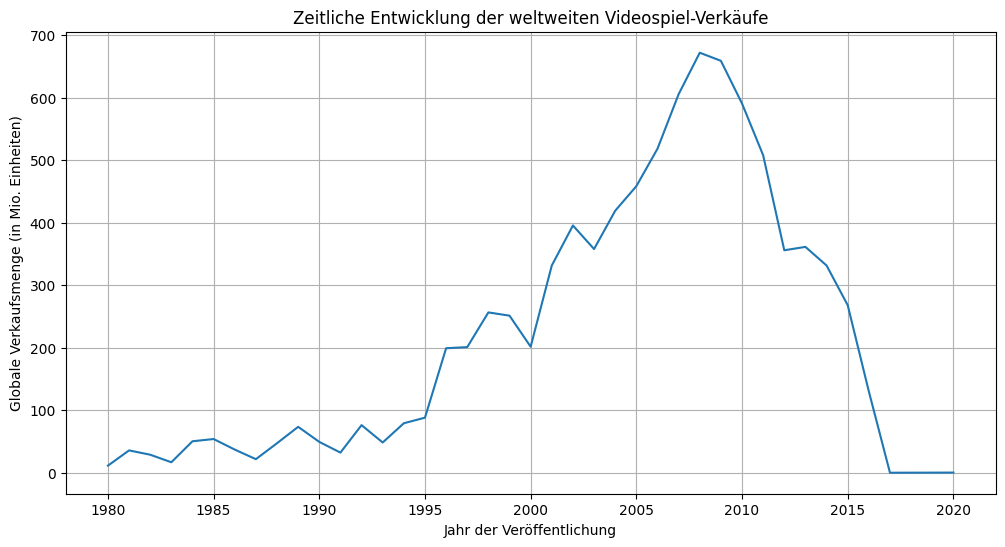

In [34]:
plt.figure(figsize=(12,6))
plt.plot(zeittrend['Year_of_Release'], zeittrend['Global_Sales'])
plt.title("Zeitliche Entwicklung der weltweiten Videospiel-Verkäufe")
plt.xlabel("Jahr der Veröffentlichung")
plt.ylabel("Globale Verkaufsmenge (in Mio. Einheiten)")
plt.grid(True)
plt.show()

In [35]:
df_2016 = df[df['Year_of_Release'] <= 2016]
df_2016.head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Region_Sum,Diff
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E,82.54,-1.000000e-02
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,Unknown,Unrated,40.24,0.000000e+00
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,35.52,7.105427e-15
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E,32.77,0.000000e+00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,Unknown,Unrated,31.38,-1.000000e-02
5,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,Unknown,Unrated,30.26,3.552714e-15
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E,29.80,0.000000e+00
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E,28.91,1.000000e-02
8,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E,28.32,0.000000e+00
9,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,Unknown,Unrated,28.31,0.000000e+00


In [36]:
df_2016['Global_Sales'].sum().round(2)

np.float64(8820.99)

In [37]:
# Zeitliche Entwicklung der globalen Verkaufszahlen pro Jahr bis 2016
zeittrend_2016 = df_2016.groupby('Year_of_Release')['Global_Sales'].sum().reset_index()

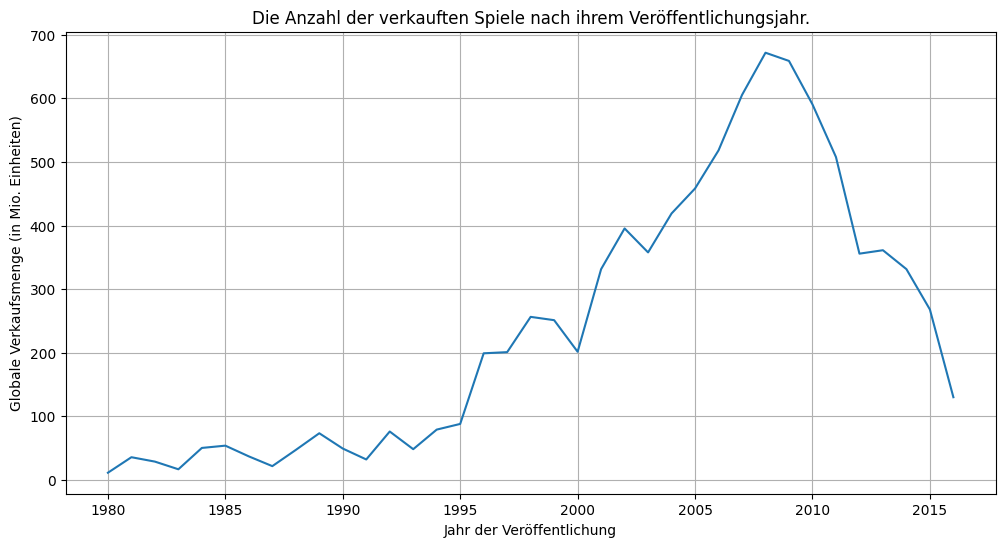

In [38]:
plt.figure(figsize=(12,6))
plt.plot(zeittrend_2016['Year_of_Release'], zeittrend_2016['Global_Sales'])
plt.title("Die Anzahl der verkauften Spiele nach ihrem Veröffentlichungsjahr.")
plt.xlabel("Jahr der Veröffentlichung")
plt.ylabel("Globale Verkaufsmenge (in Mio. Einheiten)")
plt.grid(True)
plt.show()

Man stellt fest, dass der Abwärtstrend derselbe bleibt, unabhängig davon, ob man die fehlenden Daten berücksichtigt oder nicht.    
Der Einbruch ab 2015 ist wirklich bemerkenswert, was die Menge der verkauften Videospiele betrifft.


Die beiden Hypothesen halten nicht stand, denn die Daten zeigen das Erscheinungsjahr und die gesamte Verkaufszahl bis heute.     
### Wie viele Spiele pro Jahr veröffentlicht bis 2016 wurden.  
Damit ein Gefühl für die Datenbasis und Trends in der Spieleproduktion bekommen.


In [39]:
release_per_year = df_2016["Year_of_Release"].value_counts().sort_index()

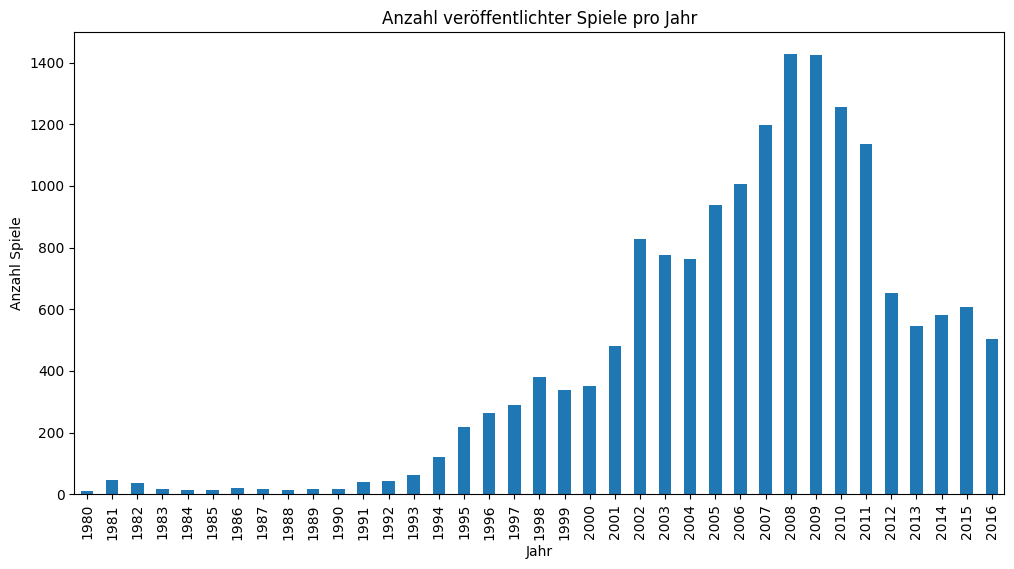

In [40]:

release_per_year.plot(kind="bar", figsize=(12,6))
plt.title("Anzahl veröffentlichter Spiele pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Anzahl Spiele")
plt.show()

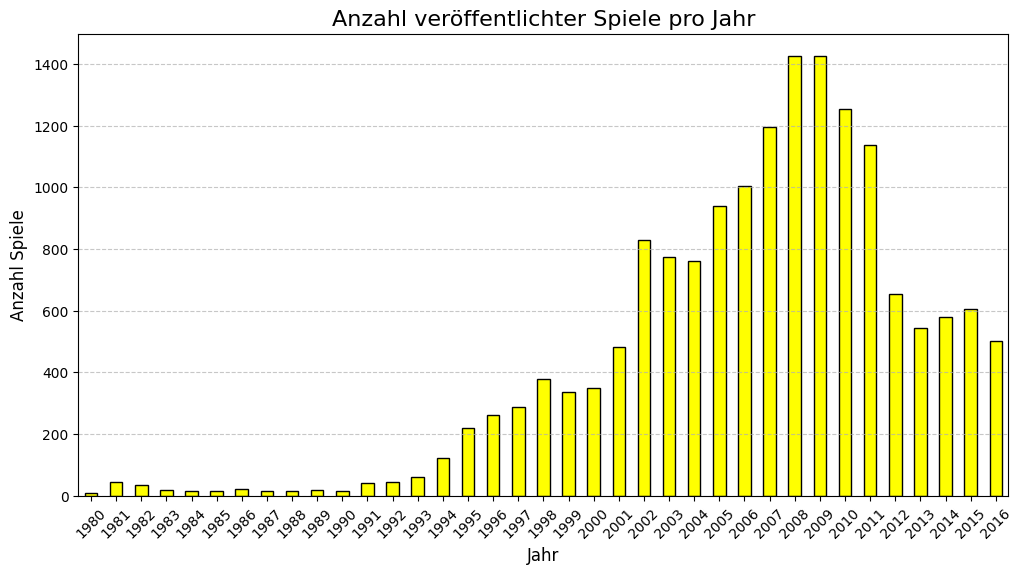

In [122]:
release_per_year.plot(kind="bar", figsize=(12,6), color="yellow", edgecolor="black")
plt.title("Anzahl veröffentlichter Spiele pro Jahr", fontsize=16)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Anzahl Spiele", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

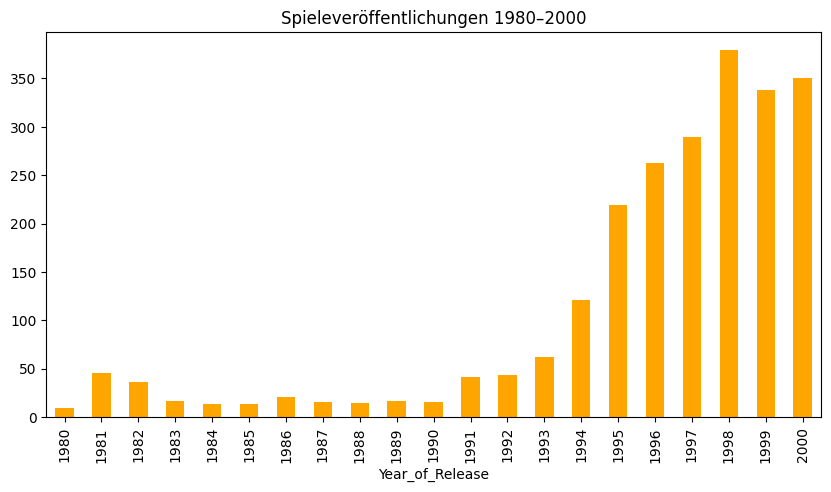

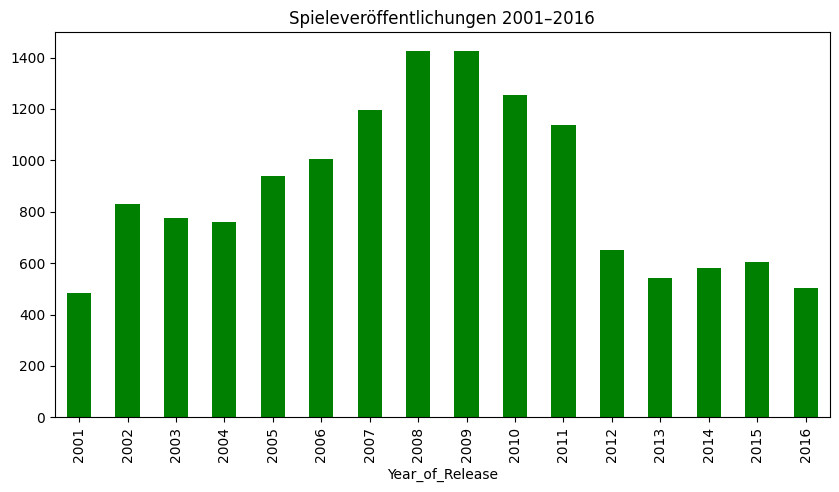

In [120]:
release_per_year.loc[1980:2000].plot(kind="bar", figsize=(10,5), color="orange")
plt.title("Spieleveröffentlichungen 1980–2000")
plt.show()

release_per_year.loc[2001:2016].plot(kind="bar", figsize=(10,5), color="green")
plt.title("Spieleveröffentlichungen 2001–2016")
plt.show()

- Man erkennt Boom-Phasen, zum Beispiel von 2002 bis 2010, als viele Konsolen aktiv waren.  
- Ebenso sind Rückgänge sichtbar, zum Beispiel nach 2011, entweder weil die Datenquelle weniger gepflegt wurde oder sich der Markt verändert hat.


# 3. Analyse pro Genre, Publisher, platformen 

## Genres
- Gibt es Genres, die sich besonders gut verkaufen?

In [41]:
global_sales_genre = (df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).round(2))

print(global_sales_genre)

Genre
Action          1745.27
Sports          1332.00
Shooter         1052.94
Role-Playing     934.40
Platform         828.08
Misc             803.18
Racing           728.90
Fighting         447.48
Simulation       390.42
Puzzle           243.02
Adventure        237.69
Strategy         174.50
Name: Global_Sales, dtype: float64


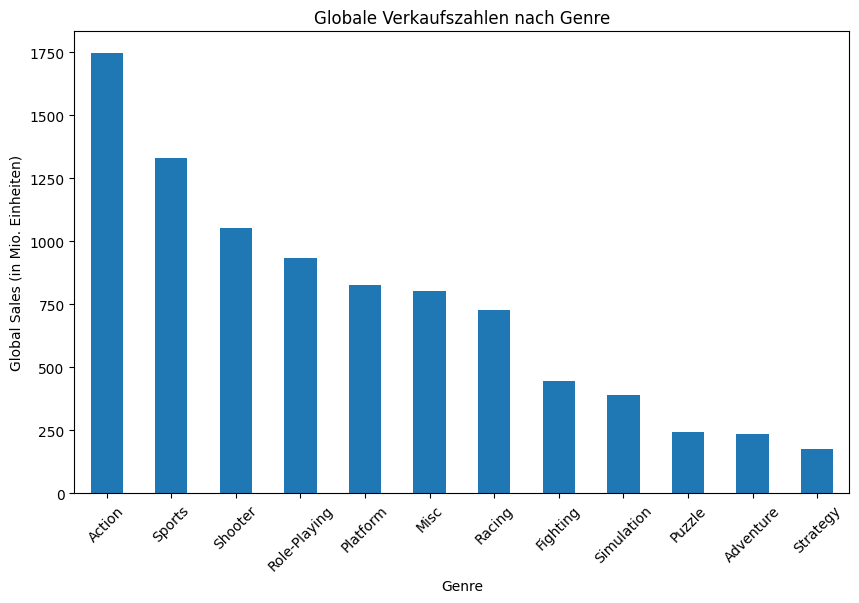

In [42]:
plt.figure(figsize=(10,6))
global_sales_genre.plot(kind='bar')
plt.title("Globale Verkaufszahlen nach Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales (in Mio. Einheiten)")
plt.xticks(rotation=45)
plt.show()

In [43]:
zeit_genre = (df.groupby(['Year_of_Release', 'Genre'])['Global_Sales'].sum().reset_index())

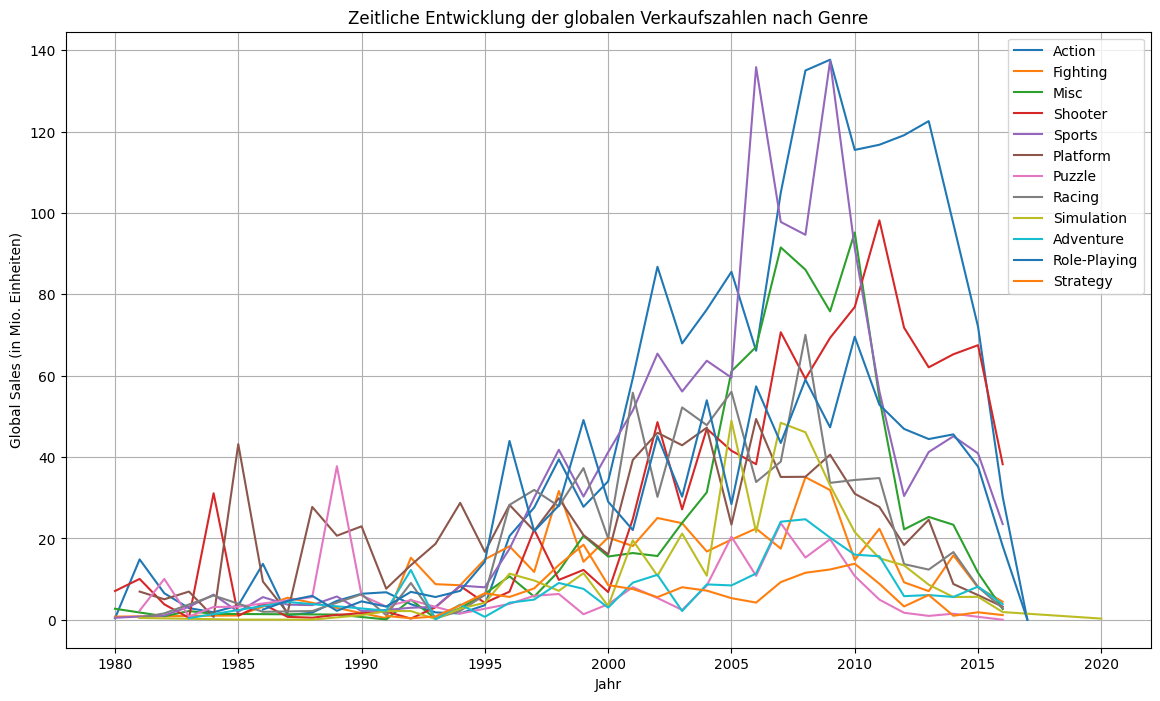

In [44]:
plt.figure(figsize=(14,8))

for genre in zeit_genre['Genre'].unique():
    subset = zeit_genre[zeit_genre['Genre'] == genre]
    plt.plot(subset['Year_of_Release'], subset['Global_Sales'], label=genre)

plt.title("Zeitliche Entwicklung der globalen Verkaufszahlen nach Genre")
plt.xlabel("Jahr")
plt.ylabel("Global Sales (in Mio. Einheiten)")
plt.legend()
plt.grid(True)
plt.show()

### Nicht lesbar wir versuchen zu verbesseren

In [45]:
# Top 5 Genres nach Gesamtverkauf
top5 = (df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(5).index)

zeit_top5 = zeit_genre[zeit_genre['Genre'].isin(top5)]

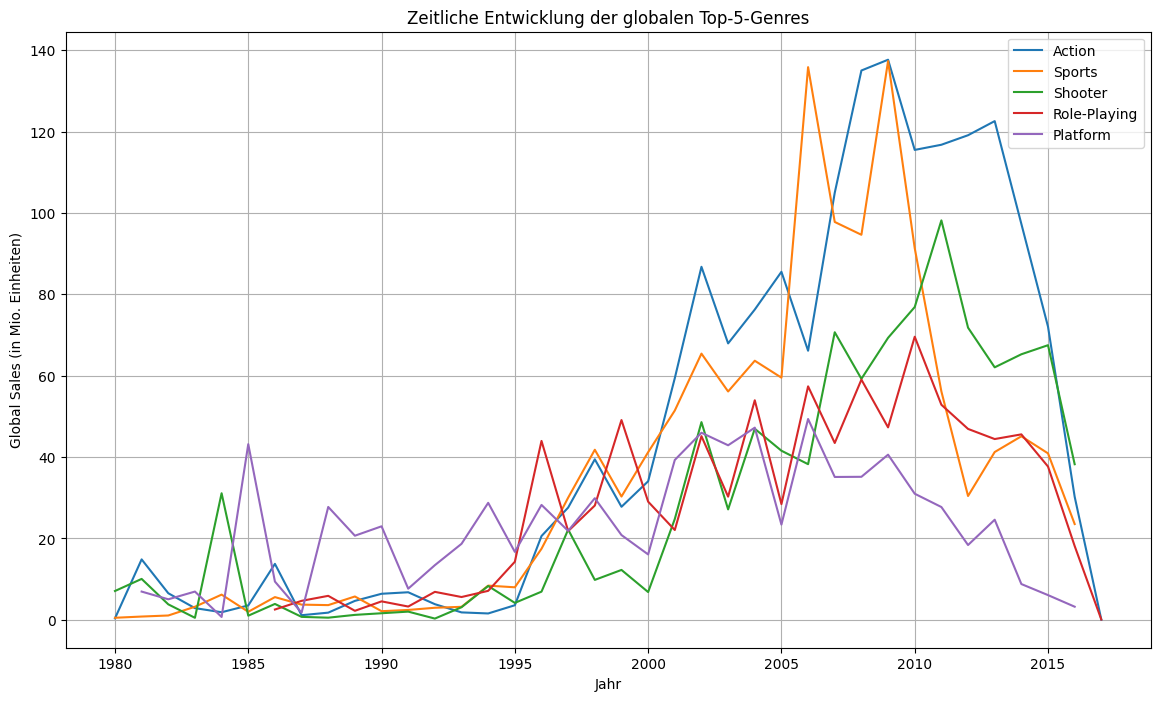

In [46]:
plt.figure(figsize=(14,8))

for genre in top5:
    subset = zeit_top5[zeit_top5['Genre'] == genre]
    plt.plot(subset['Year_of_Release'], subset['Global_Sales'], label=genre)

plt.title("Zeitliche Entwicklung der globalen Top-5-Genres")
plt.xlabel("Jahr")
plt.ylabel("Global Sales (in Mio. Einheiten)")
plt.legend()
plt.grid(True)
plt.show()

In [47]:


# Gruppieren nach Jahr und Genre, Summe der Global Sales
zeit_genre = df.groupby(['Year_of_Release','Genre'])['Global_Sales'].sum().reset_index()

# Optional: nur Jahre > 1995 für Übersicht
zeit_genre = zeit_genre[zeit_genre['Year_of_Release'] >= 1995]

# Pivotieren für Stacked Bar Chart (Jahre = Index, Genres = Spalten)
zeit_genre_pivot = zeit_genre.pivot(index='Year_of_Release', columns='Genre', values='Global_Sales').fillna(0)


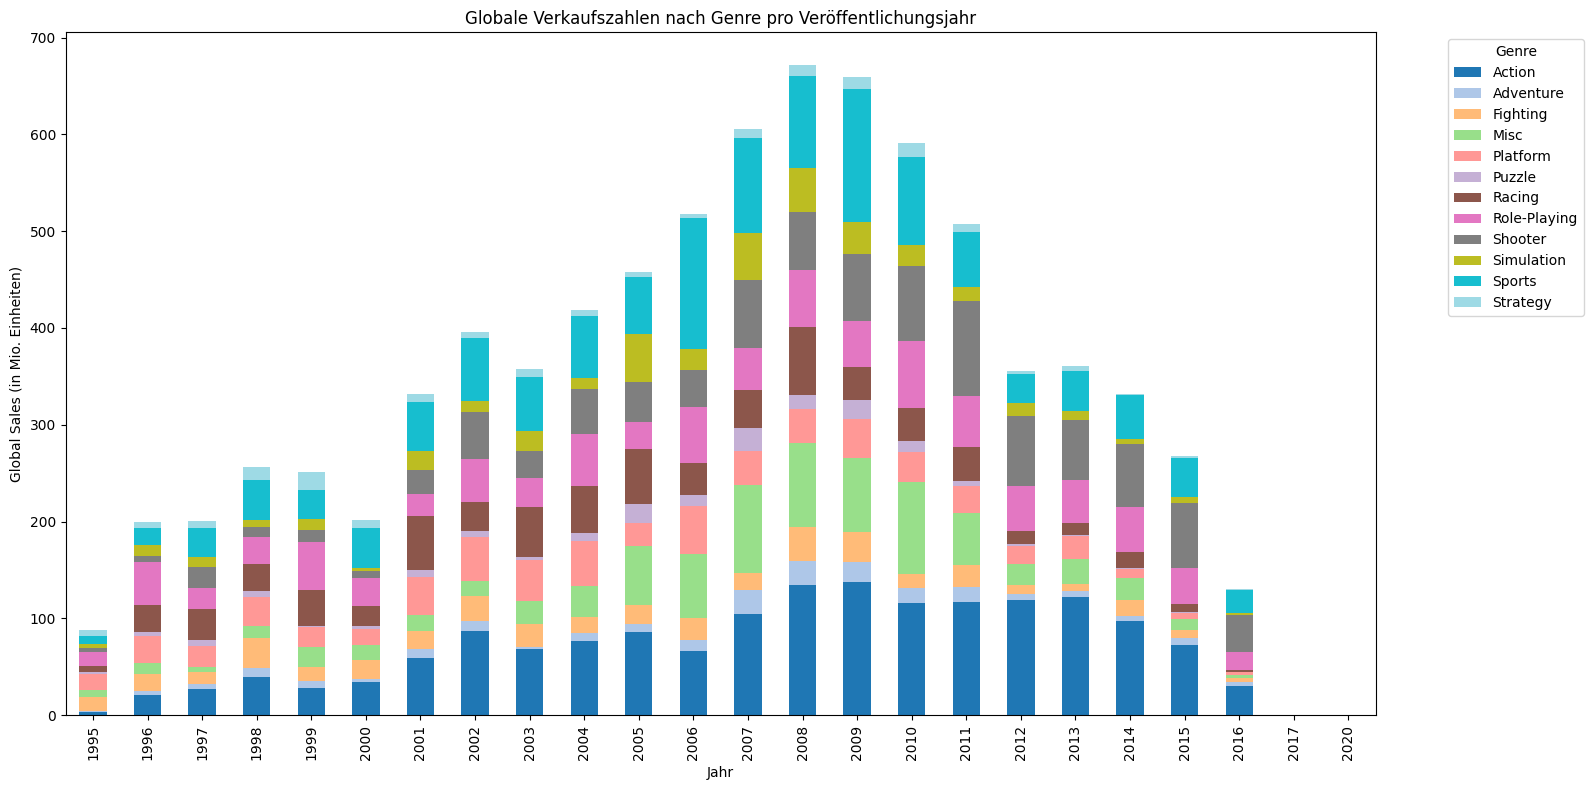

In [48]:
zeit_genre_pivot.plot(kind='bar', stacked=True, figsize=(16,8), colormap='tab20')

plt.title("Globale Verkaufszahlen nach Genre pro Veröffentlichungsjahr")
plt.xlabel("Jahr")
plt.ylabel("Global Sales (in Mio. Einheiten)")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

 Analyse nach Genre, gruppiert nach Jahr und Genre, und dabei die Summe der Entwickler (Anzahl Spiele) 

In [49]:
# "Anzahl veröffentlichter Spiele pro Genre über die Jahre
genre_year_summary = df.groupby(["Year_of_Release","Genre"]).agg({
    "Name":"count"   # Anzahl Spiele (Entwickler-Beiträge)
}).rename(columns={"Name":"Anzahl_Spiele"}).reset_index()

print(genre_year_summary.head())

   Year_of_Release     Genre  Anzahl_Spiele
0             1980    Action              1
1             1980  Fighting              1
2             1980      Misc              4
3             1980   Shooter              2
4             1980    Sports              1


## Publisher

In [50]:
# Summe der Global_Sales pro Publisher
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10).round(2)

top_publishers


Publisher
Nintendo                        1788.81
Electronic Arts                 1116.96
Activision                       731.16
Sony Computer Entertainment      606.48
Ubisoft                          471.61
Take-Two Interactive             403.82
THQ                              338.44
Konami Digital Entertainment     282.39
Sega                             270.35
Namco Bandai Games               254.62
Name: Global_Sales, dtype: float64

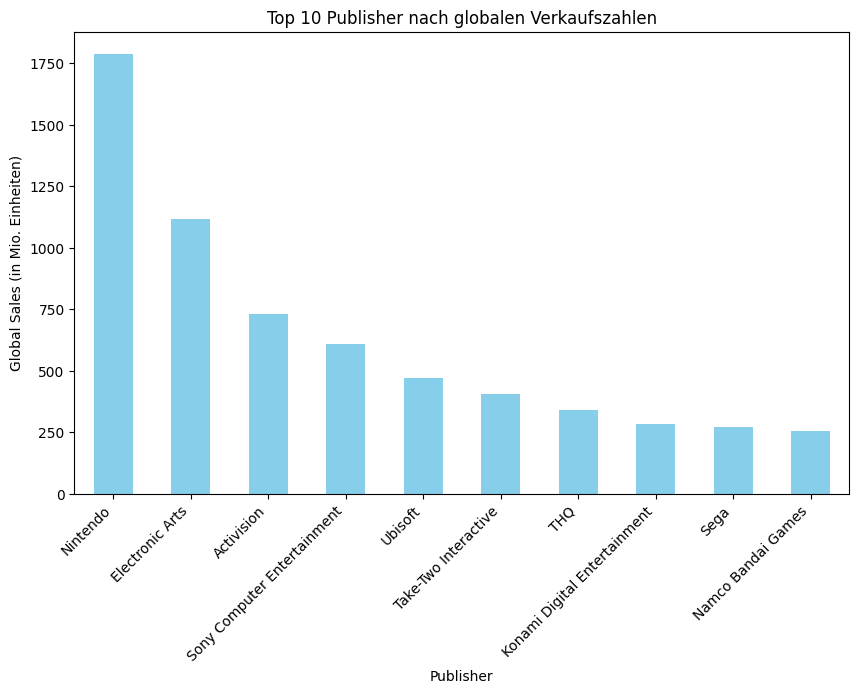

In [154]:
plt.figure(figsize=(10,6))
top_publishers.plot(kind='bar', color='skyblue')
plt.title("Top 10 Publisher nach globalen Verkaufszahlen")
plt.ylabel("Global Sales (in Mio. Einheiten)")
plt.xlabel("Publisher")
plt.xticks(rotation=45, ha='right')
plt.show()

In [52]:
publisher_counts = df["Publisher"].value_counts().head(10)
print(publisher_counts)

Publisher
Electronic Arts                 1356
Activision                       985
Namco Bandai Games               939
Ubisoft                          933
Konami Digital Entertainment     834
THQ                              715
Nintendo                         706
Sony Computer Entertainment      687
Sega                             638
Take-Two Interactive             422
Name: count, dtype: int64


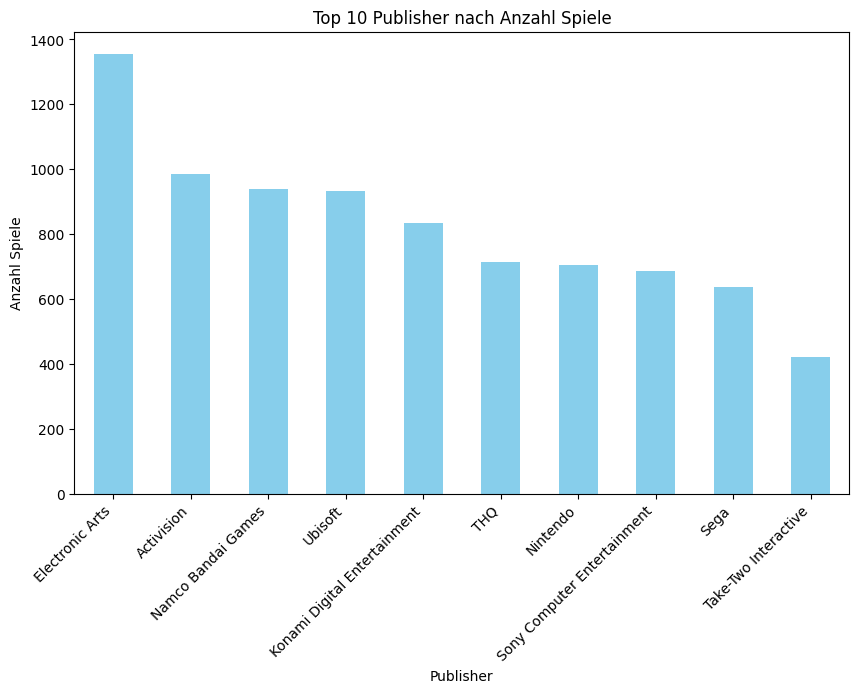

In [155]:
publisher_counts.plot(kind="bar", figsize=(10,6), color="skyblue")
plt.title("Top 10 Publisher nach Anzahl Spiele")
plt.xlabel("Publisher")
plt.ylabel("Anzahl Spiele")
plt.xticks(rotation=45, ha='right')
plt.show()

## Plattformen
- Welche Plattformen haben die meisten Spiele veröffentlicht?
➝ Das zeigt die Beliebtheit bei Entwicklern/Publishern.
- Welche Plattformen haben die höchsten globalen Verkäufe erzielt?
➝ Das zeigt die Beliebtheit bei Spielern.


In [54]:
#Anzahl Spiele pro Plattform
games_per_platform = df["Platform"].value_counts()
print(games_per_platform.head())

Platform
PS2     2161
DS      2152
PS3     1331
Wii     1320
X360    1262
Name: count, dtype: int64


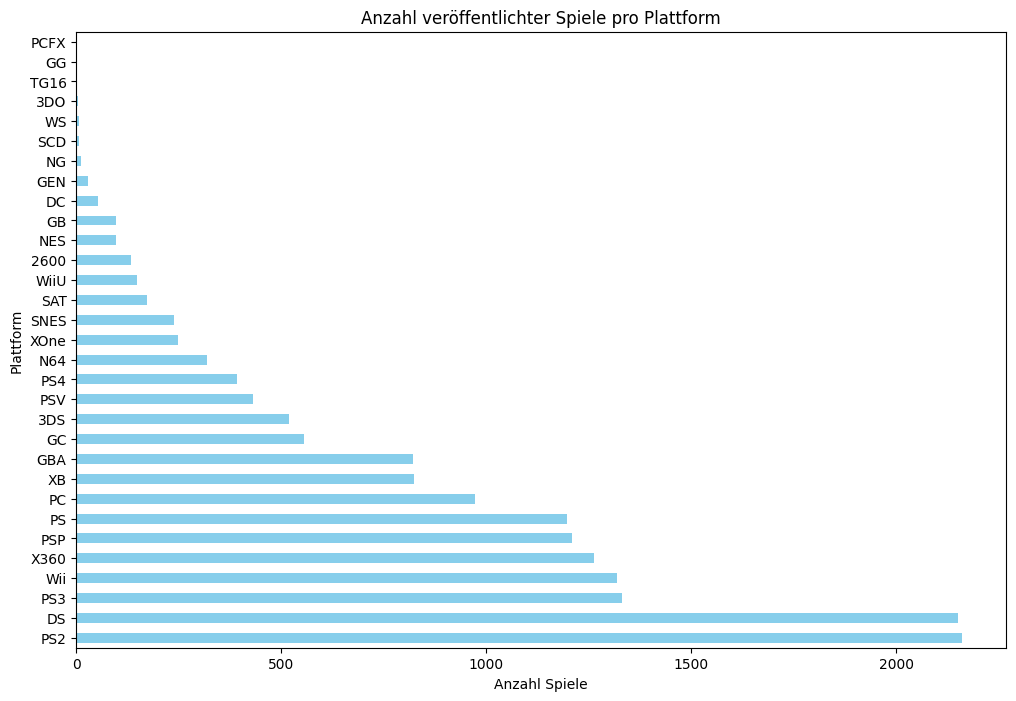

In [55]:
# Visualisierung als horizontales Balkendiagramm
games_per_platform.plot(kind="barh", figsize=(12,8), color="skyblue")
plt.title("Anzahl veröffentlichter Spiele pro Plattform")
plt.xlabel("Anzahl Spiele")
plt.ylabel("Plattform")
plt.show()


In [56]:
sales_per_platform = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
print(sales_per_platform.head())


Platform
PS2     1255.64
X360     971.63
PS3      939.43
Wii      908.13
DS       807.10
Name: Global_Sales, dtype: float64


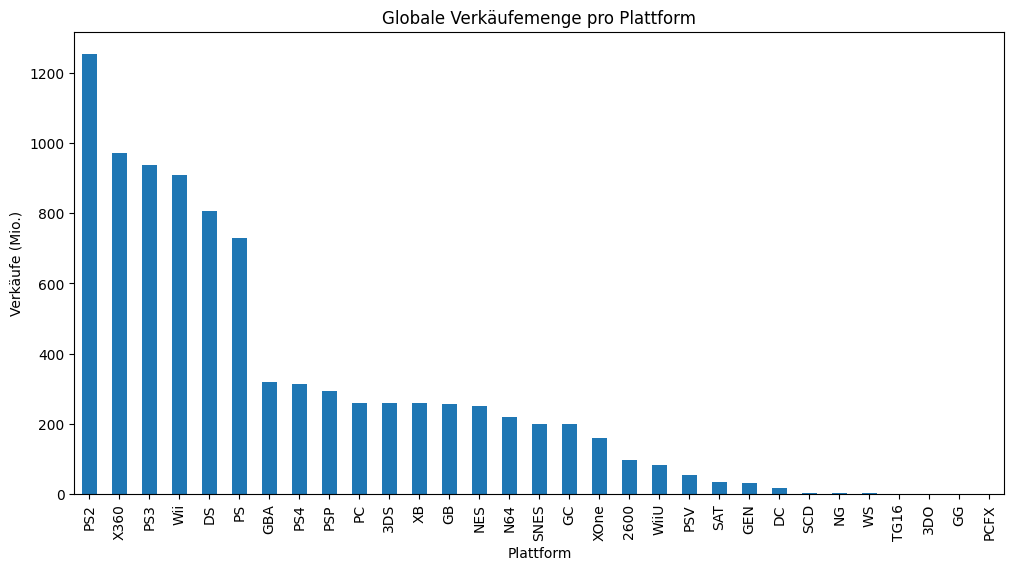

In [57]:
sales_per_platform.plot(kind="bar", figsize=(12,6))
plt.title("Globale Verkäufemenge pro Plattform")
plt.xlabel("Plattform")
plt.ylabel("Verkäufe (Mio.)")
plt.show()


In [58]:
# Beides in eine Tabelle zusammenführen
platform_summary = pd.DataFrame({
    "Anzahl_Spiele": games_per_platform,
    "Gesamt_Verkaeufe": sales_per_platform
})
platform_summary = platform_summary.sort_values("Gesamt_Verkaeufe", ascending=False)
platform_summary.head(10)

,Anzahl_Spiele,Gesamt_Verkaeufe
Platform,,
PS2,2161,1255.64
X360,1262,971.63
PS3,1331,939.43
Wii,1320,908.13
DS,2152,807.10
PS,1197,730.68
GBA,822,318.50
PS4,393,314.23
PSP,1209,294.30


## Analyse pro Region

In [59]:

# Summen pro Region
region_sales = df[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()
region_sales


NA_Sales       4402.62
EU_Sales       2424.67
JP_Sales       1297.43
Other_Sales     791.34
dtype: float64

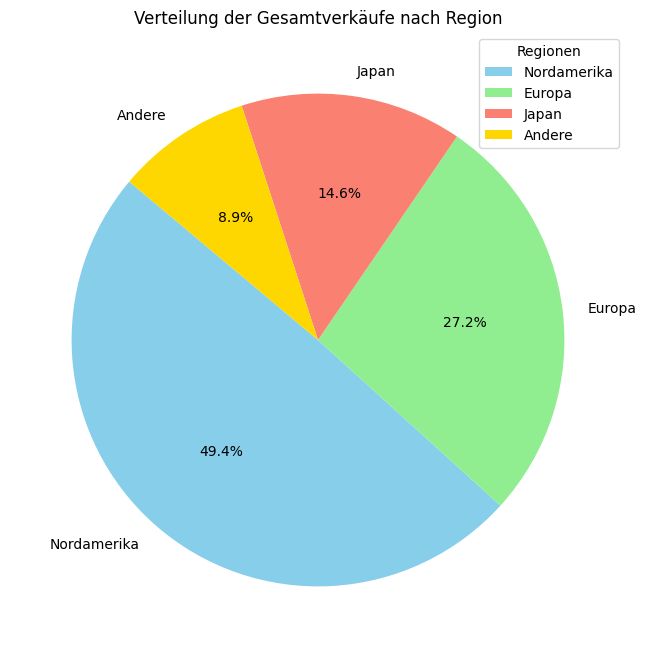

In [60]:


# Neue Labels für die Regionen
labels = ["Nordamerika", "Europa", "Japan", "Andere"]

# Kreisdiagramm
plt.figure(figsize=(8,8))
plt.pie(region_sales,
        labels=labels,              # neue Namen statt NA_Sales usw.
        autopct="%1.1f%%",          # Prozentwerte anzeigen
        startangle=140,
        colors=["skyblue","lightgreen","salmon","gold"])

plt.title("Verteilung der Gesamtverkäufe nach Region")
plt.legend(labels, title="Regionen", loc="upper right")  # Legende mit den neuen Labels
plt.show()

In [61]:
# Bestes Genre pro Region
best_genre_region = df.groupby("Genre")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()

# Für jede Region das Genre mit den höchsten Verkäufen
print(best_genre_region.idxmax())

NA_Sales             Action
EU_Sales             Action
JP_Sales       Role-Playing
Other_Sales          Action
dtype: object


In [146]:

best_game_region = {
    "NA": [
        df.loc[df["NA_Sales"].idxmax(), "Name"],
        df.loc[df["NA_Sales"].idxmax(), "Platform"],
        df.loc[df["NA_Sales"].idxmax(), "Publisher"],
        df["NA_Sales"].max()
    ],
    "EU": [
        df.loc[df["EU_Sales"].idxmax(), "Name"],
        df.loc[df["EU_Sales"].idxmax(), "Platform"],
        df.loc[df["EU_Sales"].idxmax(), "Publisher"],
        df["EU_Sales"].max()
    ],
    "JP": [
        df.loc[df["JP_Sales"].idxmax(), "Name"],
        df.loc[df["JP_Sales"].idxmax(), "Platform"],
        df.loc[df["JP_Sales"].idxmax(), "Publisher"],
        df["JP_Sales"].max()
    ],
    "Other": [
        df.loc[df["Other_Sales"].idxmax(), "Name"],
        df.loc[df["Other_Sales"].idxmax(), "Platform"],
        df.loc[df["Other_Sales"].idxmax(), "Publisher"],
        df["Other_Sales"].max()
    ],
}

# DataFrame mit zusätzlichen Spalten
best_game_table = pd.DataFrame(best_game_region, index=["Spiel","Plattform","Publisher","Verkäufe"]).T.reset_index()
best_game_table.rename(columns={"index":"Region"}, inplace=True)

best_game_table

,Region,Spiel,Plattform,Publisher,Verkäufe
0,NA,Wii Sports,Wii,Nintendo,41.36
1,EU,Wii Sports,Wii,Nintendo,28.96
2,JP,Pokemon Red/Pokemon Blue,GB,Nintendo,10.22
3,Other,Grand Theft Auto: San Andreas,PS2,Take-Two Interactive,10.57


In [142]:
# Bestes Genre pro Region
best_genre_region = df.groupby("Genre")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()

# Für jede Region das Genre mit den höchsten Verkäufen
print(best_genre_region) 

              NA_Sales  EU_Sales  JP_Sales  Other_Sales
Genre                                                  
Action          879.01    519.13    161.44       184.60
Adventure       105.26     63.54     52.30        16.49
Fighting        223.36    100.33     87.48        36.36
Misc            407.27    212.74    108.11        74.39
Platform        445.50    200.35    130.83        51.09
Puzzle          122.87     50.01     57.31        12.38
Racing          359.35    236.51     56.71        76.10
Role-Playing    330.81    188.71    355.46        59.63
Shooter         592.24    317.34     38.76       104.11
Simulation      182.19    113.52     63.80        30.75
Sports          684.43    376.79    135.54       134.51
Strategy         68.55     45.17     49.66        10.85


# Analyser der Rating

### Rating-Bedeutung

| Rating | Bedeutung |
|--------|-----------|
| E      | Everyone – für alle Altersgruppen geeignet |
| E10+   | Everyone 10+ – ab 10 Jahren |
| T      | Teen – ab 13 Jahren |
| M      | Mature – ab 17 Jahren |
| AO     | Adults Only – ab 18 Jahren |
| RP     | Rating Pending – noch keine finale Einstufung |
| EC     | Early Childhood – sehr junge Kinder |


In [63]:
df['Rating'].value_counts()

Rating
Unrated    6769
E          3991
T          2961
M          1563
E10+       1420
EC            8
K-A           3
RP            3
AO            1
Name: count, dtype: int64

C:\Users\hberh\AppData\Local\Temp\ipykernel_13040\2553912468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Rating'].value_counts().index,


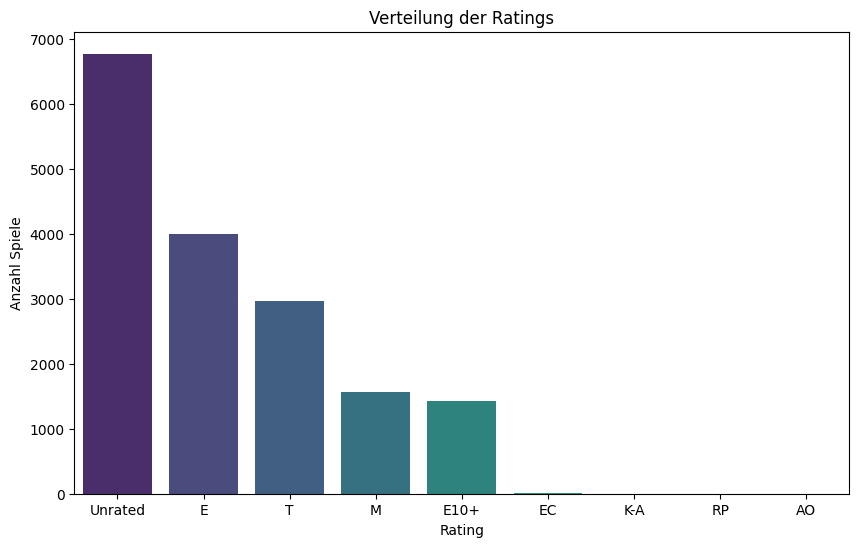

In [64]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['Rating'].value_counts().index,
            y=df['Rating'].value_counts().values,
            palette="viridis")
plt.title("Verteilung der Ratings")
plt.xlabel("Rating")
plt.ylabel("Anzahl Spiele")
plt.show()


In [65]:
#Rating nach Region (Summen der Verkäufe pro Rating)
rating_region = df.groupby("Rating")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum().reset_index()
print(rating_region)

    Rating  NA_Sales  EU_Sales  JP_Sales  Other_Sales
0       AO      1.26      0.61      0.00         0.09
1        E   1293.26    710.25    198.11       234.19
2     E10+    353.32    188.52     40.20        73.56
3       EC      1.53      0.11      0.00         0.11
4      K-A      2.56      0.27      1.46         0.03
5        M    748.48    483.97     64.24       177.10
6       RP      0.00      0.08      0.00         0.01
7        T    759.75    427.03    151.40       155.17
8  Unrated   1242.46    613.83    842.02       151.08


In [66]:
rating_genre_sales = df.groupby(["Rating","Genre"])["Global_Sales"].sum().reset_index()

In [67]:
best_genre_per_rating = rating_genre_sales.loc[
    rating_genre_sales.groupby("Rating")["Global_Sales"].idxmax()
].reset_index(drop=True)

print(best_genre_per_rating)

    Rating         Genre  Global_Sales
0       AO        Action          1.95
1        E        Sports        845.87
2     E10+        Action        219.04
3       EC          Misc          0.97
4      K-A      Strategy          2.41
5        M       Shooter        626.55
6       RP      Strategy          0.07
7        T        Action        333.76
8  Unrated  Role-Playing        420.08


In [70]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating',
       'Region_Sum', 'Diff'],
      dtype='object')

In [71]:
df['Publisher'].nunique()

581

In [72]:
df['Developer'].nunique()

1697

### History of the best Spiel ab 1980

In [73]:
best_per_year = df.loc[df.groupby("Year_of_Release")["Global_Sales"].idxmax(),
                       ["Year_of_Release","Name","Platform","Genre","Publisher","Global_Sales"]]

best_per_year.sort_values("Year_of_Release")

,Year_of_Release,Name,Platform,Genre,Publisher,Global_Sales
262,1980,Asteroids,2600,Shooter,Atari,4.31
240,1981,Pitfall!,2600,Platform,Activision,4.50
89,1982,Pac-Man,2600,Puzzle,Atari,7.81
426,1983,Baseball,NES,Sports,Nintendo,3.20
9,1984,Duck Hunt,NES,Shooter,Nintendo,28.31
1,1985,Super Mario Bros.,NES,Platform,Nintendo,40.24
124,1986,The Legend of Zelda,NES,Action,Nintendo,6.51
252,1987,Zelda II: The Adventure of Link,NES,Adventure,Nintendo,4.38
22,1988,Super Mario Bros. 3,NES,Platform,Nintendo,17.28
5,1989,Tetris,GB,Puzzle,Nintendo,30.26


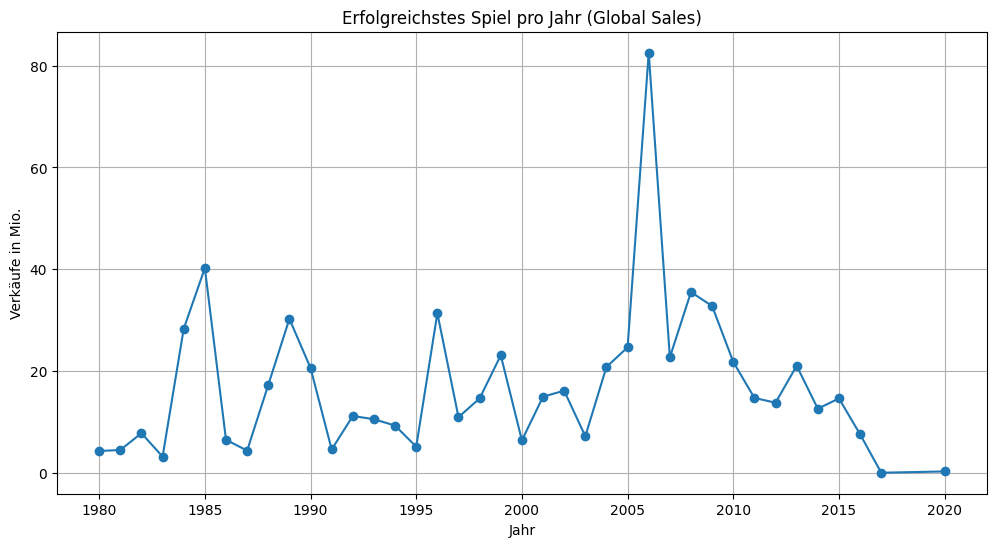

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(best_per_year["Year_of_Release"], best_per_year["Global_Sales"], marker="o")
plt.title("Erfolgreichstes Spiel pro Jahr (Global Sales)")
plt.xlabel("Jahr")
plt.ylabel("Verkäufe in Mio.")
plt.grid(True)
plt.show()

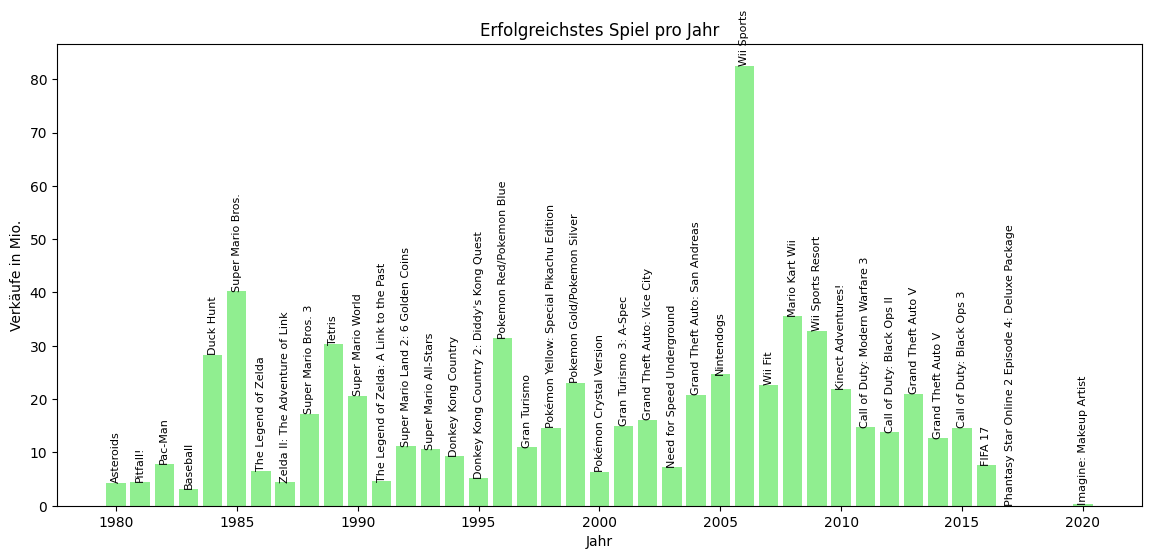

In [75]:
plt.figure(figsize=(14,6))
bars = plt.bar(best_per_year["Year_of_Release"], best_per_year["Global_Sales"], color="lightgreen")

for bar, name in zip(bars, best_per_year["Name"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), name,
             ha="center", va="bottom", rotation=90, fontsize=8)

plt.title("Erfolgreichstes Spiel pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Verkäufe in Mio.")
plt.show()

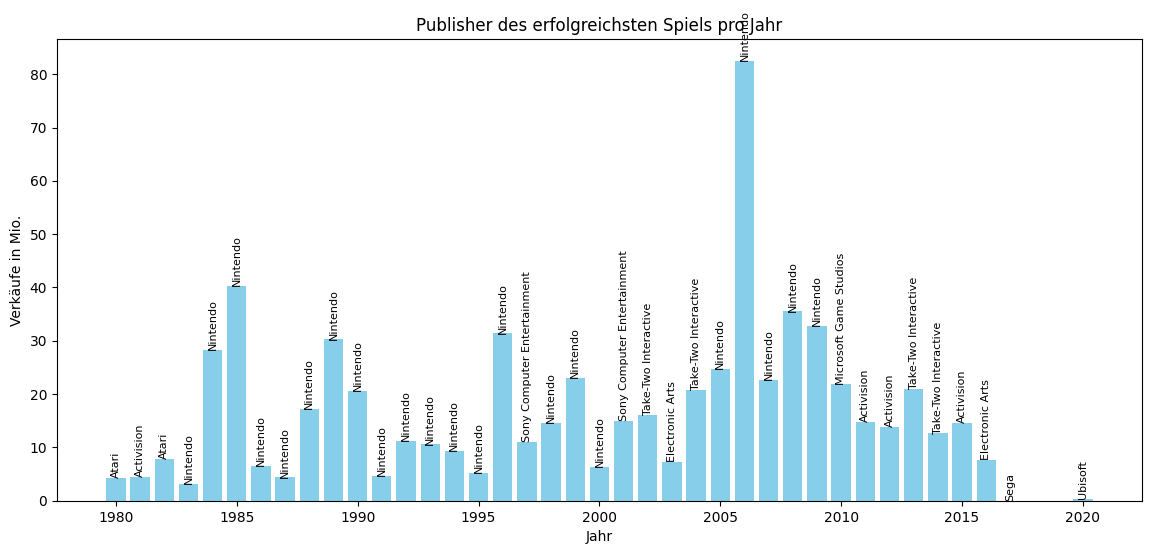

In [76]:
plt.figure(figsize=(14,6))
bars = plt.bar(best_per_year["Year_of_Release"], best_per_year["Global_Sales"], color="skyblue")

for bar, publisher in zip(bars, best_per_year["Publisher"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), publisher,
             ha="center", va="bottom", rotation=90, fontsize=8)

plt.title("Publisher des erfolgreichsten Spiels pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Verkäufe in Mio.")
plt.show()

In [77]:
ct_genre_rating = pd.crosstab(df["Genre"], df["Rating"])
print(ct_genre_rating)


Rating        AO     E  E10+  EC  K-A    M  RP    T  Unrated
Genre                                                       
Action         1   416   481   1    0  608   0  681     1182
Adventure      0   162    68   2    0   99   0  115      857
Fighting       0     8    19   0    0   49   0  362      411
Misc           0   457   167   5    1   13   0  239      868
Platform       0   358   144   0    0    3   0   64      319
Puzzle         0   289    43   0    0    0   0   10      238
Racing         0   585    96   0    0   18   1  172      377
Role-Playing   0    84   111   0    0  162   0  420      723
Shooter        0    48    58   0    0  565   0  348      304
Simulation     0   326    48   0    0    5   0  190      305
Sports         0  1188   107   0    0   16   0  198      839
Strategy       0    70    78   0    2   25   2  162      344


In [78]:
ct_pub_rating = pd.crosstab(df["Publisher"], df["Rating"])
print(ct_pub_rating.head())

Rating                        AO  E  E10+  EC  K-A  M  RP   T  Unrated
Publisher                                                             
10TACLE Studios                0  0     0   0    0  0   0   1        2
1C Company                     0  0     0   0    0  0   0   2        1
20th Century Fox Video Games   0  0     0   0    0  0   0   0        5
2D Boy                         0  1     0   0    0  0   0   0        0
3DO                            0  5     0   0    0  0   0  13       18


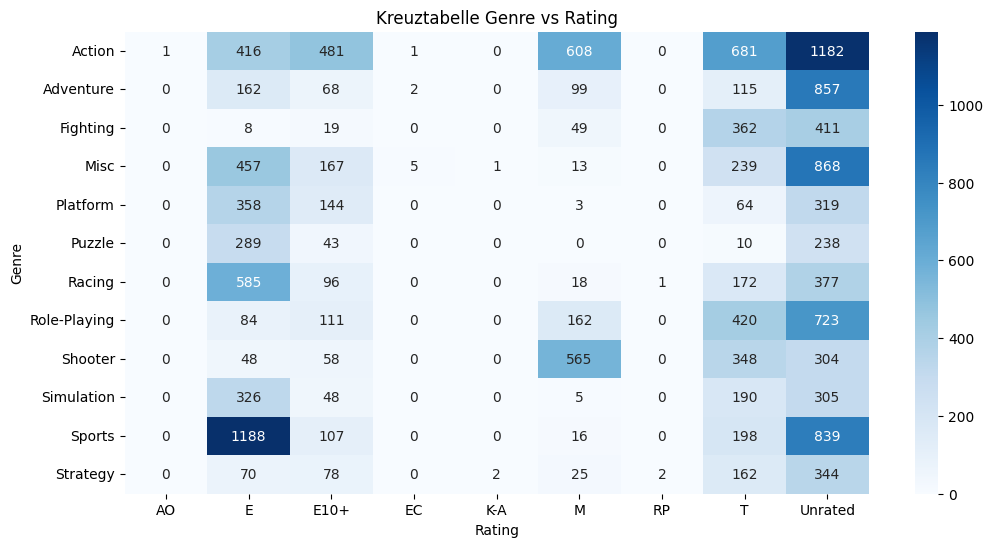

In [79]:
plt.figure(figsize=(12,6))
sns.heatmap(ct_genre_rating, annot=True, fmt="d", cmap="Blues")
plt.title("Kreuztabelle Genre vs Rating")
plt.show()


# fehlenden Werte

In [80]:
missing = df[["Critic_Score","User_Score"]].isnull().mean()*100
print(missing)

# Fehlende Werte nach Plattform
print(df.groupby("Platform")[["Critic_Score","User_Score"]].apply(lambda x: x.isnull().mean()*100))

# Fehlende Werte nach Jahr
print(df.groupby("Year_of_Release")[["Critic_Score","User_Score"]].apply(lambda x: x.isnull().mean()*100))

Critic_Score    51.330821
User_Score      40.098092
dtype: float64
          Critic_Score  User_Score
Platform                          
2600        100.000000  100.000000
3DO         100.000000  100.000000
3DS          67.692308   55.769231
DC           73.076923   73.076923
DS           66.682156   40.845725
GB          100.000000  100.000000
GBA          46.715328   37.104623
GC           19.424460   15.647482
GEN         100.000000  100.000000
GG          100.000000  100.000000
N64         100.000000  100.000000
NES         100.000000  100.000000
NG          100.000000  100.000000
PC           26.591376   15.913758
PCFX        100.000000  100.000000
PS           83.291562   82.706767
PS2          39.935215   31.466913
PS3          38.392186   27.573253
PS4          35.877863   33.078880
PSP          61.786600   55.004136
PSV          72.222222   65.277778
SAT         100.000000  100.000000
SCD         100.000000  100.000000
SNES        100.000000  100.000000
TG16        100.000000 

In [81]:
with_score = df[df["Critic_Score"].notnull()]["Global_Sales"].mean()
without_score = df[df["Critic_Score"].isnull()]["Global_Sales"].mean()

print("Durchschnittliche Verkäufe mit Score:", with_score)
print("Durchschnittliche Verkäufe ohne Score:", without_score)

Durchschnittliche Verkäufe mit Score: 0.6890352709843922
Durchschnittliche Verkäufe ohne Score: 0.3861127942204614


In [82]:
missing = df[["Critic_Score","User_Score"]].isnull().mean()*100
missing_sorted = missing.sort_values(ascending=False)
print(missing_sorted)

Critic_Score    51.330821
User_Score      40.098092
dtype: float64


In [83]:
missing_platform = df.groupby("Platform")[["Critic_Score","User_Score"]].apply(lambda x: x.isnull().mean()*100)
missing_platform_sorted = missing_platform.sort_values(by="Critic_Score", ascending=False)
print(missing_platform_sorted)

          Critic_Score  User_Score
Platform                          
2600        100.000000  100.000000
3DO         100.000000  100.000000
GB          100.000000  100.000000
NES         100.000000  100.000000
N64         100.000000  100.000000
GG          100.000000  100.000000
GEN         100.000000  100.000000
PCFX        100.000000  100.000000
NG          100.000000  100.000000
SCD         100.000000  100.000000
WS          100.000000  100.000000
SNES        100.000000  100.000000
TG16        100.000000  100.000000
SAT         100.000000  100.000000
PS           83.291562   82.706767
DC           73.076923   73.076923
PSV          72.222222   65.277778
3DS          67.692308   55.769231
DS           66.682156   40.845725
PSP          61.786600   55.004136
Wii          55.681818   24.242424
GBA          46.715328   37.104623
PS2          39.935215   31.466913
WiiU         38.775510   28.571429
PS3          38.392186   27.573253
PS4          35.877863   33.078880
XOne         31.5789

In [84]:
# Fehlende Werte pro Jahr berechnen
missing_year = df.groupby("Year_of_Release")[["Critic_Score","User_Score"]].apply(lambda x: x.isnull().mean()*100)

# Nach Critic_Score sortieren
missing_year_sorted = missing_year.sort_values(by="Year_of_Release", ascending=True)

print(missing_year_sorted)  

                 Critic_Score  User_Score
Year_of_Release                          
1980               100.000000  100.000000
1981               100.000000  100.000000
1982               100.000000  100.000000
1983               100.000000  100.000000
1984               100.000000  100.000000
1985                92.857143   92.857143
1986               100.000000  100.000000
1987               100.000000  100.000000
1988                93.333333   93.333333
1989               100.000000  100.000000
1990               100.000000  100.000000
1991               100.000000  100.000000
1992                97.674419   97.674419
1993               100.000000  100.000000
1994                99.173554   99.173554
1995               100.000000  100.000000
1996                96.958175   96.958175
1997                94.117647   93.425606
1998                92.612137   91.820580
1999                88.461538   88.461538
2000                59.142857   57.142857
2001                32.365145   29

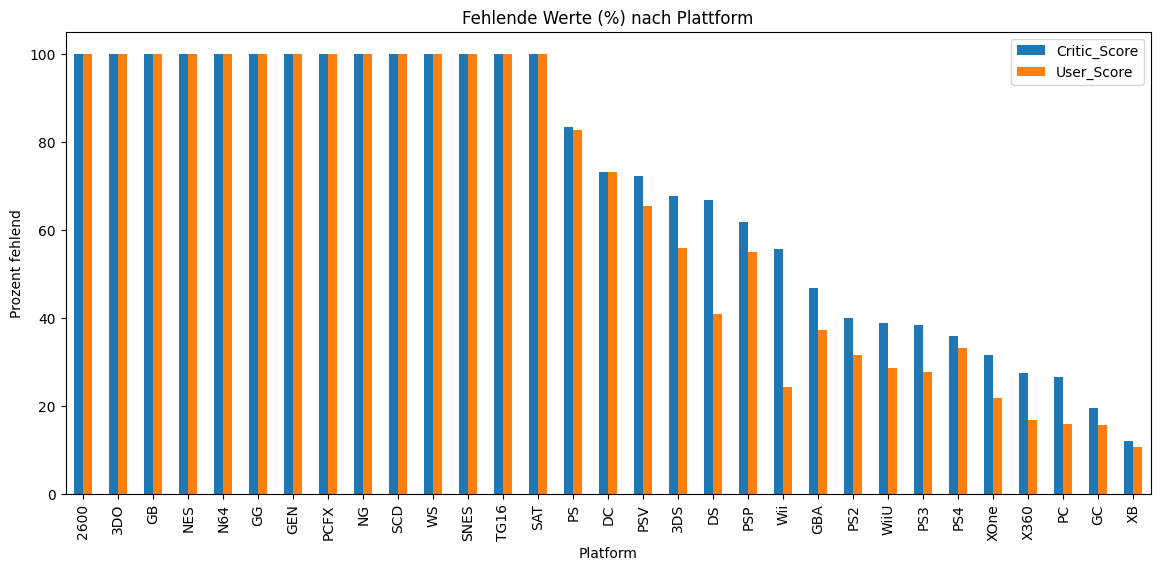

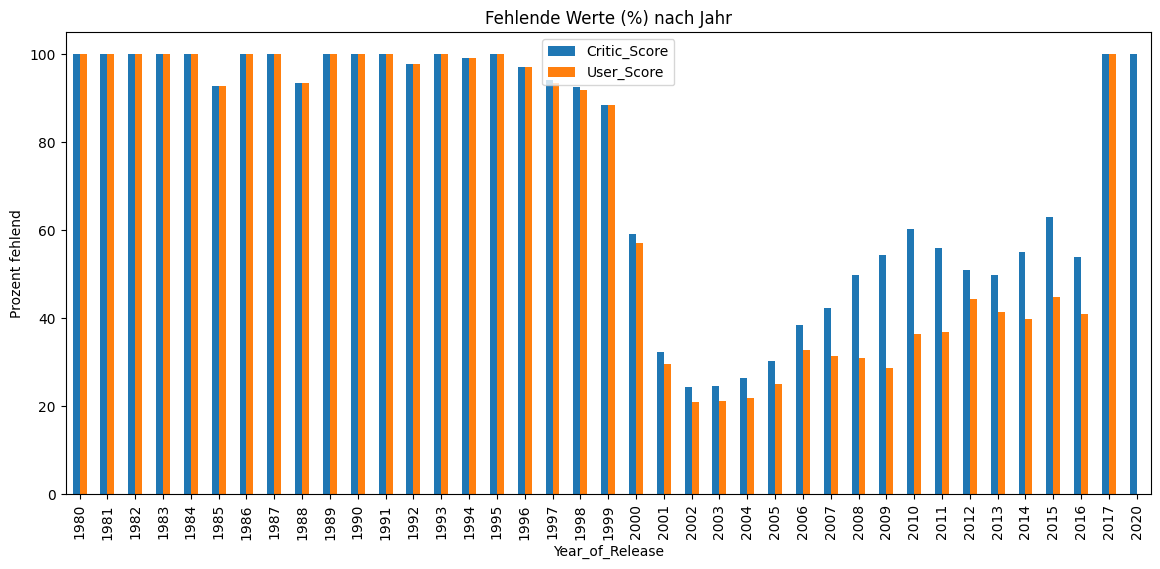

In [85]:

# Plattformen
missing_platform_sorted.plot(kind="bar", figsize=(14,6))
plt.title("Fehlende Werte (%) nach Plattform")
plt.ylabel("Prozent fehlend")
plt.show()

# Jahre
missing_year_sorted.plot(kind="bar", figsize=(14,6))
plt.title("Fehlende Werte (%) nach Jahr")
plt.ylabel("Prozent fehlend")
plt.show()

Critic_Score-Werte vor 2000 fast komplett fehlen, ist es sinnvoll, dein DataFrame auf die Jahre 2000 bis 2016 zu beschränken.


In [86]:
# Neues DataFrame nur mit Spielen von 2000 bis 2016
df_2000_2016 = df[(df["Year_of_Release"] >= 2000) & (df["Year_of_Release"] <= 2016)]

df_2000_2016.head(10)  # zeigt die ersten Zeilen

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Region_Sum,Diff
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E,82.54,-1.000000e-02
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,35.52,7.105427e-15
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E,32.77,0.000000e+00
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E,29.80,0.000000e+00
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E,28.91,1.000000e-02
8,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E,28.32,0.000000e+00
10,Nintendogs,DS,2005,Simulation,Nintendo,9.05,10.95,1.93,2.74,24.67,NaN,NaN,NaN,NaN,Unknown,Unrated,24.67,0.000000e+00
11,Mario Kart DS,DS,2005,Racing,Nintendo,9.71,7.47,4.13,1.90,23.21,91.0,64.0,8.6,464.0,Nintendo,E,23.21,3.552714e-15
13,Wii Fit,Wii,2007,Sports,Nintendo,8.92,8.03,3.60,2.15,22.70,80.0,63.0,7.7,146.0,Nintendo,E,22.70,0.000000e+00
14,Kinect Adventures!,X360,2010,Misc,Microsoft Game Studios,15.00,4.89,0.24,1.69,21.81,61.0,45.0,6.3,106.0,Good Science Studio,E,21.82,-1.000000e-02


In [87]:

print(df_2000_2016.shape)   # zeigt Anzahl Zeilen und Spalten
df_2000_2016.isnull().sum()

(14470, 18)


Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher            32
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       6583
Critic_Count       6583
User_Score         4732
User_Count         7099
Developer             0
Rating                0
Region_Sum            0
Diff                  0
dtype: int64

In [88]:
print(df.shape)
df.isnull().sum()

(16719, 18)


Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer             0
Rating                0
Region_Sum            0
Diff                  0
dtype: int64

In [89]:
# Anzahl der Spiele bis einschließlich 2000
spiele_bis_2000 = df[df["Year_of_Release"] <= 2000].shape[0]

print("Anzahl der Spiele bis 2000:", spiele_bis_2000)

Anzahl der Spiele bis 2000: 2326


In [90]:
df_2000_2016['Publisher'].value_counts()

Publisher
Electronic Arts                 1236
Activision                       920
Ubisoft                          910
Namco Bandai Games               847
Konami Digital Entertainment     700
                                ... 
Commseed                           1
UIG Entertainment                  1
Takuyo                             1
Interchannel-Holon                 1
Red Flagship                       1
Name: count, Length: 460, dtype: int64

In [91]:
# Anzahl fehlender Critic_Score pro Publisher
missing_critic_counts = df_2000_2016[df_2000_2016["Critic_Score"].isnull()]["Publisher"].value_counts()
missing_critic_counts


Publisher
Namco Bandai Games              575
Konami Digital Entertainment    384
Activision                      362
Ubisoft                         359
THQ                             285
                               ... 
Takuyo                            1
Interchannel-Holon                1
Red Flagship                      1
Trion Worlds                      1
Kemco                             1
Name: count, Length: 375, dtype: int64

In [93]:
# Fehlende Werte von 2000_2016 pro Publisher berechnen
missing_publisher = df_2000_2016.groupby("Publisher")[["Critic_Score","User_Score"]]\
                      .apply(lambda x: x.isnull().mean()*100)
missing_publisher = missing_publisher.reset_index()
# Nach Critic_Score sortieren (absteigend)
missing_publisher_sorted = missing_publisher.sort_values(by="Critic_Score", ascending=False)

missing_publisher_sorted #Publisher mit den meisten fehlenden Werten

,Publisher,Critic_Score,User_Score
9,ASCII Entertainment,100.0,100.0
459,responDESIGN,100.0,100.0
10,ASCII Media Works,100.0,100.0
458,"mixi, Inc",100.0,100.0
456,imageepoch Inc.,100.0,100.0
...,...,...,...
436,Wargaming.net,0.0,0.0
439,White Park Bay Software,0.0,0.0
457,inXile Entertainment,0.0,0.0
2,2D Boy,0.0,0.0


In [94]:
publisher_100 = missing_publisher[(missing_publisher["Critic_Score"] == 100) & 
                                  (missing_publisher["User_Score"] == 100)]

publisher_100 = publisher_100.reset_index()

print("Publisher mit 100% fehlenden Werten:")
publisher_100

Publisher mit 100% fehlenden Werten:


,index,Publisher,Critic_Score,User_Score
0,4,49Games,100.0,100.0
1,7,7G//AMES,100.0,100.0
2,9,ASCII Entertainment,100.0,100.0
3,10,ASCII Media Works,100.0,100.0
4,11,Abylight,100.0,100.0
...,...,...,...,...
127,453,dramatic create,100.0,100.0
128,454,fonfun,100.0,100.0
129,456,imageepoch Inc.,100.0,100.0
130,458,"mixi, Inc",100.0,100.0


In [98]:
publisher_0 = missing_publisher[(missing_publisher["Critic_Score"] == 0) & 
                                (missing_publisher["User_Score"] == 0)]
publisher_0 = publisher_0.reset_index()

print("Publisher mit 0% fehlenden Werten:")
publisher_0

Publisher mit 0% fehlenden Werten:


,index,Publisher,Critic_Score,User_Score
0,1,1C Company,0.0,0.0
1,2,2D Boy,0.0,0.0
2,16,Activision Blizzard,0.0,0.0
3,43,Avalon Interactive,0.0,0.0
4,55,Black Label Games,0.0,0.0
...,...,...,...,...
80,432,Visco,0.0,0.0
81,436,Wargaming.net,0.0,0.0
82,439,White Park Bay Software,0.0,0.0
83,444,Yacht Club Games,0.0,0.0


- 132 Publisher → keine Spiele mit Critic_Score (alles fehlt)
- 85 Publisher → 100 % Critic_Score vorhanden (keine fehlenden Werte)
- Rest → die „gemischten“ Publisher, bei denen ein Teil der Spiele bewertet wurde und ein Teil nicht


In [96]:
publisher_partial = missing_publisher[(missing_publisher["Critic_Score"] > 0) & 
                                      (missing_publisher["Critic_Score"] < 100)]

In [97]:
publisher_partial.sort_values(by='Critic_Score')

,Publisher,Critic_Score,User_Score
215,Kemco,8.333333,8.333333
259,Microids,9.090909,9.090909
419,Universal Interactive,9.090909,4.545455
442,Xplosiv,10.000000,0.000000
211,Kalypso Media,11.538462,3.846154
...,...,...,...
225,Level 5,92.592593,92.592593
415,UFO Interactive,93.750000,0.000000
183,Idea Factory,93.893130,92.366412
27,Aqua Plus,95.454545,95.454545


In [99]:
df_2000_2016["Publisher"].nunique()


460

Analyse für den Zeitraum 2000–2016 ergibt also:
- 132 Publisher → haben keine Kritikerbewertungen (100 % fehlend)
- 85 Publisher → haben vollständige Kritikerbewertungen (0 % fehlend)
- 206 Publisher → sind teilweise bewertet (ein Teil der Spiele hat Critic_Scores, ein Teil nicht)


         Gruppe  Anzahl Publisher
0  100% fehlend               132
1    0% fehlend                85
2     Teilweise               206


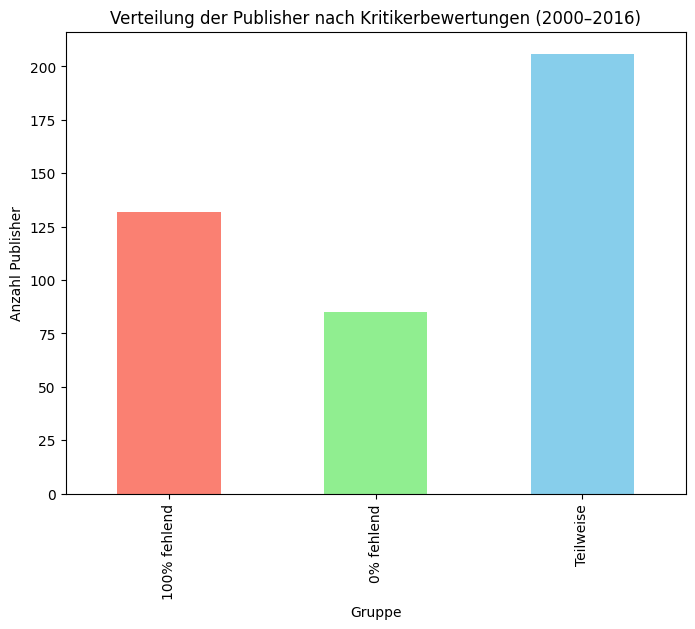

In [100]:
summary = pd.DataFrame({
    "Gruppe": ["100% fehlend", "0% fehlend", "Teilweise"],
    "Anzahl Publisher": [132, 85, 206]
})
print(summary)

summary.plot(kind="bar", x="Gruppe", y="Anzahl Publisher", 
             color=["salmon","lightgreen","skyblue"], legend=False, figsize=(8,6))
plt.title("Verteilung der Publisher nach Kritikerbewertungen (2000–2016)")
plt.ylabel("Anzahl Publisher")
plt.show()

In [101]:
# Summe der Global_Sales pro Publisher
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10).round(2)

top_publishers

Publisher
Nintendo                        1788.81
Electronic Arts                 1116.96
Activision                       731.16
Sony Computer Entertainment      606.48
Ubisoft                          471.61
Take-Two Interactive             403.82
THQ                              338.44
Konami Digital Entertainment     282.39
Sega                             270.35
Namco Bandai Games               254.62
Name: Global_Sales, dtype: float64

In [102]:
top_publishers_list = [
    "Nintendo",
    "Electronic Arts",
    "Activision",
    "Sony Computer Entertainment",
    "Ubisoft",
    "Take-Two Interactive",
    "THQ",
    "Konami Digital Entertainment",
    "Sega",
    "Namco Bandai Games"
]

# Prüfen, in welcher Gruppe die Top-Publisher sind
top_in_0 = publisher_0[publisher_0["Publisher"].isin(top_publishers_list)]
top_in_100 = publisher_100[publisher_100["Publisher"].isin(top_publishers_list)]
top_in_partial = publisher_partial[publisher_partial["Publisher"].isin(top_publishers_list)]

print("Top Publisher mit 0% fehlend:\n", top_in_0)
print("Top Publisher mit 100% fehlend:\n", top_in_100)
print("Top Publisher teilweise fehlend:\n", top_in_partial)

Top Publisher mit 0% fehlend:
 Empty DataFrame
Columns: [index, Publisher, Critic_Score, User_Score]
Index: []
Top Publisher mit 100% fehlend:
 Empty DataFrame
Columns: [index, Publisher, Critic_Score, User_Score]
Index: []
Top Publisher teilweise fehlend:
                         Publisher  Critic_Score  User_Score
15                     Activision     39.347826   16.086957
109               Electronic Arts     18.122977    9.142395
220  Konami Digital Entertainment     54.857143   47.428571
278            Namco Bandai Games     67.886659   63.990555
287                      Nintendo     41.587902   41.398866
353                          Sega     38.986355   38.206628
360   Sony Computer Entertainment     37.853107   33.709981
389                           THQ     41.424419   23.255814
393          Take-Two Interactive     28.676471   12.009804
417                       Ubisoft     39.450549   14.285714


In [103]:
# Global Sales pro Publisher in der 0%-Gruppe
publisher_0_sales = df.groupby("Publisher")["Global_Sales"].sum().reset_index()

# Nur die Publisher aus der 0%-Gruppe auswählen
publisher_0_sales = publisher_0_sales[publisher_0_sales["Publisher"].isin(publisher_0["Publisher"])]

# Sortieren nach Global_Sales absteigend
publisher_0_sales = publisher_0_sales.sort_values(by="Global_Sales", ascending=False).round(2)

print(publisher_0_sales.head(20))  # zeigt die Top 20 Publisher mit 0% fehlenden Werten

                               Publisher  Global_Sales
428                            RedOctane          8.68
165                      Fox Interactive          7.39
465                               Square          3.64
537                       Valve Software          3.20
222                          Hello Games          1.70
536                                Valve          1.70
517                           Touchstone          1.56
453                 Slightly Mad Studios          1.48
459  Sony Computer Entertainment America          1.26
71                     Black Label Games          1.20
191              Gathering of Developers          1.19
258                   Jester Interactive          1.15
468                         Square Enix           0.99
499                            TalonSoft          0.87
216               Harmonix Music Systems          0.85
187                           Gamebridge          0.73
236                   Illusion Softworks          0.70
313       

In [104]:
total_sales = df["Global_Sales"].sum()
print("Gesamtmarkt (Global Sales):", round(total_sales,2))

Gesamtmarkt (Global Sales): 8920.3


In [105]:
publisher_0_sales = df.groupby("Publisher")["Global_Sales"].sum().reset_index()
publisher_0_sales = publisher_0_sales[publisher_0_sales["Publisher"].isin(publisher_0["Publisher"])]

# Summe der Global Sales dieser Gruppe
publisher_0_total = publisher_0_sales["Global_Sales"].sum()
print("Global Sales der Publisher mit 0% fehlend:", round(publisher_0_total,2))

Global Sales der Publisher mit 0% fehlend: 48.27


In [ ]:
publisher_0_share = (publisher_0_total / total_sales) * 100
print("Anteil am Gesamtmarkt (%):", round(publisher_0_share,2))

Anteil am Gesamtmarkt (%): 0.54


In [106]:
# Gesamtmarkt (alle Global Sales)
total_sales = df["Global_Sales"].sum()

# Global Sales pro Publisher
publisher_sales = df.groupby("Publisher")["Global_Sales"].sum().reset_index()

# Nur die Publisher mit 100% fehlenden Werten auswählen
publisher_100_sales = publisher_sales[publisher_sales["Publisher"].isin(publisher_100["Publisher"])]

# Summe der Global Sales dieser Gruppe
publisher_100_total = publisher_100_sales["Global_Sales"].sum()

# Anteil berechnen
publisher_100_share = (publisher_100_total / total_sales) * 100

print("Global Sales der Publisher mit 100% fehlend:", round(publisher_100_total,2))
print("Anteil am Gesamtmarkt (%):", round(publisher_100_share,2))

Global Sales der Publisher mit 100% fehlend: 66.69
Anteil am Gesamtmarkt (%): 0.75


- Beide Gruppen zusammen machen nur etwa 1.3 % des gesamten Marktes aus.
- Das bedeutet: fast der gesamte Marktanteil (≈ 98.7 %) liegt bei den „Partial Publishern“, also den großen Playern wie Nintendo, EA, Activision, Sony, Ubisoft usw., die zwar viele Spiele haben, aber nicht alle mit Kritikerbewertungen versehen sind.
- Die Gruppen „0 % fehlend“ und „100 % fehlend“ sind eher Randgruppen:
- 0 % fehlend → kleinere Publisher, deren Spiele alle bewertet wurden, aber mit geringem Verkaufsvolumen.
- 100 % fehlend → ebenfalls kleinere Publisher


In [107]:
# Gesamtmarkt (alle Global Sales)
total_sales = df["Global_Sales"].sum()

# Verkäufe 1980–2000
sales_1980_2000 = df[(df["Year_of_Release"] >= 1980) & (df["Year_of_Release"] <= 2000)]["Global_Sales"].sum()

# Verkäufe 2000–2016
sales_2000_2016 = df[(df["Year_of_Release"] >= 2000) & (df["Year_of_Release"] <= 2016)]["Global_Sales"].sum()

# Anteile berechnen
share_1980_2000 = (sales_1980_2000 / total_sales) * 100
share_2000_2016 = (sales_2000_2016 / total_sales) * 100

print("Global Sales 1980–2000:", round(sales_1980_2000,2))
print("Anteil am Gesamtmarkt 1980–2000 (%):", round(share_1980_2000,2))

print("Global Sales 2000–2016:", round(sales_2000_2016,2))
print("Anteil am Gesamtmarkt 2000–2016 (%):", round(share_2000_2016,2))

Global Sales 1980–2000: 1859.47
Anteil am Gesamtmarkt 1980–2000 (%): 20.85
Global Sales 2000–2016: 7163.1
Anteil am Gesamtmarkt 2000–2016 (%): 80.3


In [ ]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating',
       'Region_Sum', 'Diff'],
      dtype='object')

In [108]:
# Alle Publisher, die in der Partial-Gruppe sind
publisher_partial_list = publisher_partial["Publisher"].unique()

# Neues DataFrame mit allen Spalten für diese Publisher
df_top_market = df_2000_2016[df_2000_2016["Publisher"].isin(publisher_partial_list)].copy()

print(df_top_market.columns)   # zeigt alle Spalten

df_top_market.head()   # zeigt die ersten Zeilen


Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating',
       'Region_Sum', 'Diff'],
      dtype='object')


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Region_Sum,Diff
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E,82.54,-1.000000e-02
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,35.52,7.105427e-15
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E,32.77,0.000000e+00
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E,29.80,0.000000e+00
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E,28.91,1.000000e-02


In [109]:
df_top_market.drop(['Region_Sum', 'Diff'], axis=1, inplace=True)

In [110]:
df_top_market.reset_index()

,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
2,3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
3,6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
4,7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13661,16714,Samurai Warriors: Sanada Maru,PS3,2016,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,Unknown,Unrated
13662,16715,LMA Manager 2007,X360,2006,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,Unknown,Unrated
13663,16716,Haitaka no Psychedelica,PSV,2016,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,Unknown,Unrated
13664,16717,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,Unknown,Unrated


In [111]:
critic_min = df_top_market["Critic_Score"].min()
critic_max = df_top_market["Critic_Score"].max()

print("Critic Score min:", critic_min)
print("Critic Score max:", critic_max)

Critic Score min: 13.0
Critic Score max: 98.0


In [112]:
df_top_market['Critic_Score']

0        76.0
2        82.0
3        80.0
6        89.0
7        58.0
         ... 
16714     NaN
16715     NaN
16716     NaN
16717     NaN
16718     NaN
Name: Critic_Score, Length: 13666, dtype: float64

In [113]:
df_top_market['User_Score']

0          8
2        8.3
3          8
6        8.5
7        6.6
        ... 
16714    NaN
16715    NaN
16716    NaN
16717    NaN
16718    NaN
Name: User_Score, Length: 13666, dtype: object

In [114]:
# Zuerst 'tbd' oder andere nicht-numerische Werte in NaN umwandeln
df_top_market["User_Score"] = df_top_market["User_Score"].replace("tbd", np.nan)

# Dann in float konvertieren
df_top_market["User_Score"] = df_top_market["User_Score"].astype(float)

print(df_top_market["User_Score"].dtype)

float64


In [115]:
user_min = df_top_market["User_Score"].min()
user_max = df_top_market["User_Score"].max()

print("User Score min:", user_min)
print("User Score max:", user_max)

User Score min: 0.0
User Score max: 9.7


In [116]:
top5_critic = df_top_market.sort_values(by="Critic_Score", ascending=False)[
    ["Name","Publisher","Year_of_Release","Platform","Genre","Global_Sales","Critic_Score"]
].head(5)

print("Top 5 Spiele nach Critic Score:")
top5_critic

Top 5 Spiele nach Critic Score:


,Name,Publisher,Year_of_Release,Platform,Genre,Global_Sales,Critic_Score
51,Grand Theft Auto IV,Take-Two Interactive,2008,X360,Action,11.01,98.0
57,Grand Theft Auto IV,Take-Two Interactive,2008,PS3,Action,10.50,98.0
227,Tony Hawk's Pro Skater 2,Activision,2000,PS,Sports,4.68,98.0
97,Super Mario Galaxy 2,Nintendo,2010,Wii,Platform,7.51,97.0
42,Grand Theft Auto V,Take-Two Interactive,2014,PS4,Action,12.61,97.0


In [ ]:
top5_user = df_top_market.sort_values(by="User_Score", ascending=False)[
    ["Name","Publisher","Year_of_Release","Platform","Genre","Global_Sales","User_Score"]
].head(5)

print("Top 5 Spiele nach User Score:")
top5_user

Top 5 Spiele nach User Score:


,Name,Publisher,Year_of_Release,Platform,Genre,Global_Sales,User_Score
14414,Breath of Fire III,Capcom,2005,PSP,Role-Playing,0.03,9.7
8976,Boktai: The Sun is in Your Hand,Konami Digital Entertainment,2003,GBA,Role-Playing,0.15,9.6
3417,Harvest Moon: Friends of Mineral Town,Ubisoft,2003,GBA,Simulation,0.59,9.6
16631,Karnaaj Rally,Jaleco,2003,GBA,Racing,0.01,9.5
5920,MLB SlugFest Loaded,Midway Games,2004,PS2,Sports,0.30,9.5


In [117]:
best_per_year = df.loc[df.groupby("Year_of_Release")["Global_Sales"].idxmax(),
                       ["Year_of_Release","Name","Platform","Genre","Publisher","Global_Sales", "User_Score", "Critic_Score", "Rating" ]]

best_per_year.sort_values("Year_of_Release")

,Year_of_Release,Name,Platform,Genre,Publisher,Global_Sales,User_Score,Critic_Score,Rating
262,1980,Asteroids,2600,Shooter,Atari,4.31,NaN,NaN,Unrated
240,1981,Pitfall!,2600,Platform,Activision,4.50,NaN,NaN,Unrated
89,1982,Pac-Man,2600,Puzzle,Atari,7.81,NaN,NaN,Unrated
426,1983,Baseball,NES,Sports,Nintendo,3.20,NaN,NaN,Unrated
9,1984,Duck Hunt,NES,Shooter,Nintendo,28.31,NaN,NaN,Unrated
1,1985,Super Mario Bros.,NES,Platform,Nintendo,40.24,NaN,NaN,Unrated
124,1986,The Legend of Zelda,NES,Action,Nintendo,6.51,NaN,NaN,Unrated
252,1987,Zelda II: The Adventure of Link,NES,Adventure,Nintendo,4.38,NaN,NaN,Unrated
22,1988,Super Mario Bros. 3,NES,Platform,Nintendo,17.28,NaN,NaN,Unrated
5,1989,Tetris,GB,Puzzle,Nintendo,30.26,NaN,NaN,Unrated


In [118]:
df_top_market.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13666 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             13666 non-null  object 
 1   Platform         13666 non-null  object 
 2   Year_of_Release  13666 non-null  Int64  
 3   Genre            13666 non-null  object 
 4   Publisher        13666 non-null  object 
 5   NA_Sales         13666 non-null  float64
 6   EU_Sales         13666 non-null  float64
 7   JP_Sales         13666 non-null  float64
 8   Other_Sales      13666 non-null  float64
 9   Global_Sales     13666 non-null  float64
 10  Critic_Score     7721 non-null   float64
 11  Critic_Count     7721 non-null   float64
 12  User_Score       7223 non-null   float64
 13  User_Count       7223 non-null   float64
 14  Developer        13666 non-null  object 
 15  Rating           13666 non-null  object 
dtypes: Int64(1), float64(9), object(6)
memory usage: 1.8+ MB


In [ ]:
best_rating_region = df.groupby("Rating")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()
best_rating_region

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Rating,,,,
AO,1.26,0.61,0.00,0.09
E,1293.26,710.25,198.11,234.19
E10+,353.32,188.52,40.20,73.56
EC,1.53,0.11,0.00,0.11
K-A,2.56,0.27,1.46,0.03
M,748.48,483.97,64.24,177.10
RP,0.00,0.08,0.00,0.01
T,759.75,427.03,151.40,155.17
Unrated,1242.46,613.83,842.02,151.08


In [143]:
best_genre_region


,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,879.01,519.13,161.44,184.60
Adventure,105.26,63.54,52.30,16.49
Fighting,223.36,100.33,87.48,36.36
Misc,407.27,212.74,108.11,74.39
Platform,445.50,200.35,130.83,51.09
Puzzle,122.87,50.01,57.31,12.38
Racing,359.35,236.51,56.71,76.10
Role-Playing,330.81,188.71,355.46,59.63
Shooter,592.24,317.34,38.76,104.11


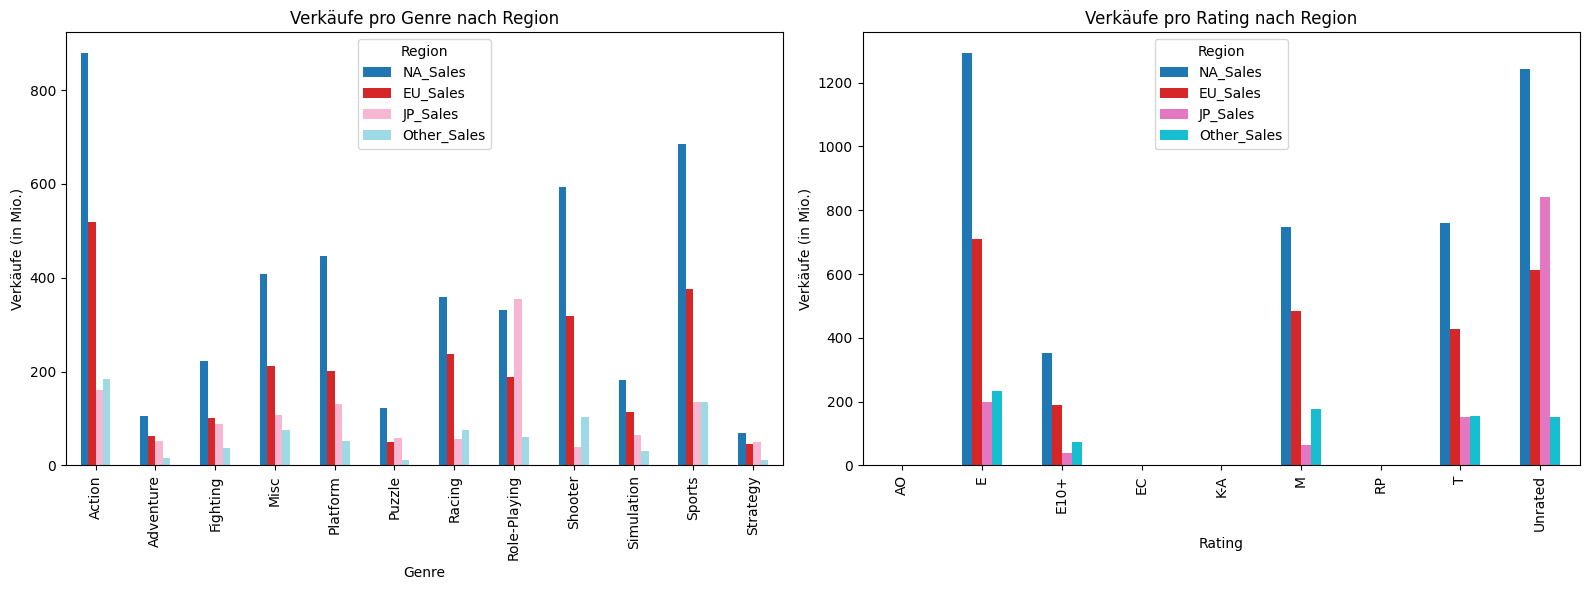

In [147]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(16,6))

best_genre_region.plot(kind="bar", ax=axes[0], colormap="tab20")
axes[0].set_title("Verkäufe pro Genre nach Region")
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Verkäufe (in Mio.)")
axes[0].legend(title="Region")

best_rating_region.plot(kind="bar", ax=axes[1], colormap="tab10")
axes[1].set_title("Verkäufe pro Rating nach Region")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Verkäufe (in Mio.)")
axes[1].legend(title="Region")

plt.tight_layout()
plt.show()

In [148]:
df_2000_2016.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating',
       'Region_Sum', 'Diff'],
      dtype='object')

In [161]:
df_top_market.sort_values(by="Global_Sales", ascending=False).head(20)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E
10,Nintendogs,DS,2005,Simulation,Nintendo,9.05,10.95,1.93,2.74,24.67,NaN,NaN,NaN,NaN,Unknown,Unrated
11,Mario Kart DS,DS,2005,Racing,Nintendo,9.71,7.47,4.13,1.90,23.21,91.0,64.0,8.6,464.0,Nintendo,E
13,Wii Fit,Wii,2007,Sports,Nintendo,8.92,8.03,3.60,2.15,22.70,80.0,63.0,7.7,146.0,Nintendo,E
14,Kinect Adventures!,X360,2010,Misc,Microsoft Game Studios,15.00,4.89,0.24,1.69,21.81,61.0,45.0,6.3,106.0,Good Science Studio,E


In [162]:
correlation = df_top_market["Global_Sales"].corr(df_top_market["Critic_Score"])
print("Korrelation zwischen Global Sales und Critic Score:", correlation)

Korrelation zwischen Global Sales und Critic Score: 0.23877099984831443


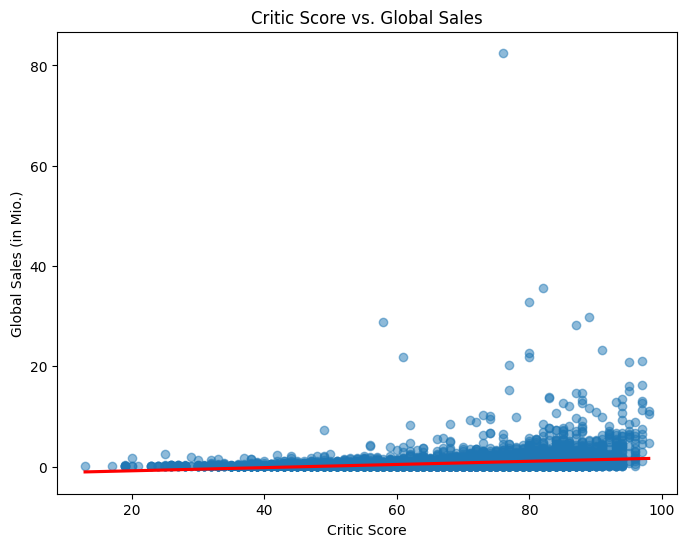

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(x="Critic_Score", y="Global_Sales", data=df_top_market,
            scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Critic Score vs. Global Sales")
plt.xlabel("Critic Score")
plt.ylabel("Global Sales (in Mio.)")
plt.show()

In [164]:
correlation_user = df_top_market["Global_Sales"].corr(df_top_market["User_Score"])
print("Korrelation zwischen Global Sales und User Score:", correlation_user)

Korrelation zwischen Global Sales und User Score: 0.08139564362114261


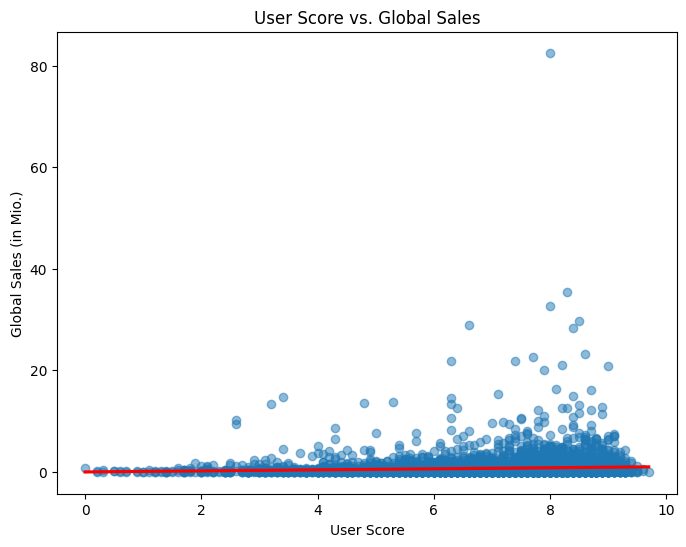

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(x="User_Score", y="Global_Sales", data=df_top_market,
            scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("User Score vs. Global Sales")
plt.xlabel("User Score")
plt.ylabel("Global Sales (in Mio.)")
plt.show()